In [1]:
# Imports and Configurations
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time

# Clustering and distance metrics
from dtaidistance import dtw
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

# Parallelization
import multiprocessing as mp

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

np.random.seed(42)

# Configuration
BENCHMARK      = '^GSPC'
RISK_FREE_RATE = 0.045
START_DATE     = '2005-01-01'
END_DATE       = '2026-01-01'
ROLLING_WINDOW = 52
MIN_HIST       = 400
K_VALUES       = [2, 4, 7]
N_CORES        = 10

# Three-period out-of-sample validation framework (20-year-window)
TRAIN_START = '2005-01-01'
TRAIN_END   = '2010-12-31'   # 6 years
VAL_START   = '2011-01-01'
VAL_END     = '2017-12-31'   # 7 years
TEST_START  = '2018-01-01'
TEST_END    = '2025-12-31'   # 7 years

# Strategy Parameters (tightened version of Notebook 6)
ZSCORE_WINDOW   = 52
VOL_WINDOW      = 26
VOL_THRESHOLD   = 1.5
HIGH_VOL_ENTRY  = 2.25  # was 2.5
LOW_VOL_ENTRY   = 1.25  # was 1.5
STANDARD_ENTRY  = 1.75  # was 2.0
EXIT_THRESHOLD  = 0.5
STOP_LOSS       = 3.25  # was 3.5

print('Notebook 7: DTW vs OCP vs TOP Clustering - S&P 500, 20-Year Three-Period Framework')
print(f'Train:  {TRAIN_START} to {TRAIN_END} (6 years)')
print(f'Val:    {VAL_START} to {VAL_END} (7 years)')
print(f'Test:   {TEST_START} to {TEST_END} (7 years)')

Notebook 7: DTW vs OCP vs TOP Clustering - S&P 500, 20-Year Three-Period Framework
Train:  2005-01-01 to 2010-12-31 (6 years)
Val:    2011-01-01 to 2017-12-31 (7 years)
Test:   2018-01-01 to 2025-12-31 (7 years)


In [2]:
import re

# Retrieving S&P 500 constitutents as of January 1, 2005

# Survivorship-bias free source
hist_url = (
    'https://raw.githubusercontent.com/fja05680/sp500/master/'
    'S%26P%20500%20Historical%20Components%20%26%20Changes.csv'
)

hist = pd.read_csv(hist_url)
hist['date'] = pd.to_datetime(hist['date'])

# Targeting the row closest to our date
target_date = pd.Timestamp('2005-01-01')
snapshot_row = hist[hist['date'] <= target_date].sort_values('date').iloc[-1]

print(f'Using snapshot date: {snapshot_row["date"].date()}')

sp500_tickers_2005 = sorted(snapshot_row['tickers'].split(','))

raw_tickers = sorted(snapshot_row['tickers'].split(','))

# Stipping the dataset's own "-YYYYMM" delisting_date suffix convention
suffix_pattern = re.compile(r'-\d{6}$')

sp500_tickers_2005 = sorted(set(
    suffix_pattern.sub('', t.strip()).replace('.','-')
    for t in raw_tickers
))

n_suffixed = sum(1 for t in raw_tickers if suffix_pattern.search(t.strip()))
print(f'Tickers with a delisting-date suffix in the source data: {n_suffixed}')
print(f'S&P 500 constituents as of {target_date.date()}: {len(sp500_tickers_2005)} stocks')
print(f'\nFirst 10 tickers: {sp500_tickers_2005[:10]}')

Using snapshot date: 2004-12-30
Tickers with a delisting-date suffix in the source data: 179
S&P 500 constituents as of 2005-01-01: 495 stocks

First 10 tickers: ['A', 'AABA', 'AAPL', 'ABC', 'ABI', 'ABKFQ', 'ABS', 'ABT', 'ACS', 'ACV']


In [3]:
# Downloading price data for this S&P 500 205 universe
import yfinance as yf

print(f'Downloading price data for {len(sp500_tickers_2005)} stocks...')
print(f'Period: {START_DATE} to {END_DATE}, weekly (Wednesday), adjusted close\n')

raw = yf.download(
    sp500_tickers_2005,
    start=START_DATE,
    end=END_DATE,
    interval='1wk',
    auto_adjust=True,
    progress=True
)

price_data = raw['Close']
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')

# Dropping any tickers without complete history across the full history
before_drop = price_data.shape[1]
price_data  = price_data.ffill().dropna(axis=1)
after_drop  = price_data.shape[1]

# Dropping any tickers that are flatlined through the end of the series
TAIL_WINDOW = 10

flatlined = []
for t in price_data.columns:
    tail = price_data[t].iloc[-TAIL_WINDOW:]
    if tail.nunique() == t:
        flatlined.append(t)

price_data = price_data.drop(columns=flatlined)
after_drop = price_data.shape[1]

print(f'\nPrice data shape: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Tickers with complete history: {after_drop} (dropped {before_drop - after_drop} incomplete/delisted)')

dropped_tickers = sorted(set(sp500_tickers_2005) - set(price_data.columns))
print(f'\nDropped tickers ({len(dropped_tickers)}): {dropped_tickers}')
        

Period: 2005-01-01 to 2026-01-01, weekly (Wednesday), adjusted close



$HET: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$BMET: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$ESRX: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$ARNC: possibly delisted; no timezone found      ]  11 of 495 completed
$EOP: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$CHIR: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$SFA: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01)
$AGN: possibly delisted; no timezone found       ]  24 of 495 completed
$BHGE: possibly delisted; no timezone found      ]  25 of 495 completed
$AT: possibly delisted; no timezone found        ]  26 of 495 completed
$CBS: possibly delisted; no timezone found       ]  27 of 495 completed
$EKDKQ: possibly delisted; no timezone found     ]  28 of 495 completed
$EA: possibly delisted; no price data found  (1wk 2005-01-01 -> 2026-01-01) (Yahoo error = "Data doesn'


Price data shape: (1096, 267)
Date range: 2005-01-05 to 2025-12-31
Tickers with complete history: 267 (dropped 228 incomplete/delisted)

Dropped tickers (228): ['AABA', 'ABC', 'ABI', 'ABKFQ', 'ABS', 'ACS', 'ACV', 'ADCT', 'AET', 'AGN', 'ALTR', 'AMCC', 'ANDW', 'ANTM', 'APC', 'APCC', 'APOL', 'ARNC', 'ASN', 'ASO', 'AT', 'AV', 'AVP', 'AW', 'AYE', 'BCR', 'BDK', 'BEAM', 'BHGE', 'BIG', 'BJS', 'BK', 'BLL', 'BLS', 'BMC', 'BMET', 'BMS', 'BNI', 'BOL', 'BR', 'BRCM', 'BSC', 'BUD', 'CA', 'CBE', 'CBS', 'CBSS', 'CCE', 'CCTYQ', 'CEG', 'CFC', 'CHIR', 'CIN', 'CITGQ', 'CMA', 'CMVT', 'CMX', 'COL', 'CPNLQ', 'CPWR', 'CTB', 'CTL', 'CTX', 'CTXS', 'DALRQ', 'DCNAQ', 'DELL', 'DG', 'DJ', 'DOW', 'DPHIQ', 'DYN', 'EA', 'EC', 'EDS', 'EKDKQ', 'EMC', 'EOP', 'ESRX', 'ETFC', 'FDC', 'FDO', 'FII', 'FOXA', 'FRX', 'FSH', 'FSL', 'FTR', 'G', 'GAS', 'GDT', 'GDW', 'GENZ', 'GLK', 'GP', 'GPS', 'GR', 'GTW', 'HCA', 'HCR', 'HES', 'HET', 'HLT', 'HMA', 'HNZ', 'HOT', 'HPC', 'HSH', 'HSP', 'IGT', 'IPG', 'IR', 'JAVA', 'JCP', 'JNS', 'JNY', '

In [4]:
print("""
    Data source limitation note (for methodology section / paper draft):

    yfinance does not serve historical price data for tickers that have 
    been delisted, regardless of how far in the past the requested date 
    range is. This means our S&P 500 2005 universe is effectively: '
    constituents as of Jan 2005 whose historical data remains accessible 
    via Yahoo Finance as of the analysis date' (2026), not strictly 
    'constituents as of Jan 2005.' Companies that were acquired, taken 
    private, or delisted at any point between 2005 and today are absent
    even thought they had complete price history during the actual 
    2005-2025 study window. This effect is matierally more substantial 
    here than in a shorter window, since a 20-year span captures far more 
    corporate turnover.
""")

print("""
    This is a known constraint of free retail data verndors and differs
    from the CRSP/WRDS standard in academic finance, which preserves
    full historical records for delisted securities. Disclosed here as a 
    limitation rather than corrected, due to project resources.
""")


    Data source limitation note (for methodology section / paper draft):

    yfinance does not serve historical price data for tickers that have 
    been delisted, regardless of how far in the past the requested date 
    range is. This means our S&P 500 2005 universe is effectively: '
    constituents as of Jan 2005 whose historical data remains accessible 
    via Yahoo Finance as of the analysis date' (2026), not strictly 
    'constituents as of Jan 2005.' Companies that were acquired, taken 
    private, or delisted at any point between 2005 and today are absent
    even thought they had complete price history during the actual 
    2005-2025 study window. This effect is matierally more substantial 
    here than in a shorter window, since a 20-year span captures far more 
    corporate turnover.


    This is a known constraint of free retail data verndors and differs
    from the CRSP/WRDS standard in academic finance, which preserves
    full historical records for delisted 

In [5]:
# Computing weekly log returns
log_returns = np.log(price_data / price_data.shift(1))

# Computing rolling sharpe ratio (risk-free-rate adjusted)
weekly_rf = RISK_FREE_RATE / 52

rolling_mean = log_returns.rolling(window=ROLLING_WINDOW).mean()
rolling_std = log_returns.rolling(window=ROLLING_WINDOW).std()

sharpe_data = ((rolling_mean - weekly_rf) / rolling_std) * np.sqrt(52)
sharpe_data = sharpe_data.dropna(how='all')

print(f'Sharpe data range: {sharpe_data.shape}')
print(f'Date range: {sharpe_data.index[0].date()} to {sharpe_data.index[-1].date()}')
print(f'\nSample (first 5 stocks, last 5 weeks):')
print(sharpe_data.iloc[-5:, :5])

Sharpe data range: (1044, 267)
Date range: 2006-01-04 to 2025-12-31

Sample (first 5 stocks, last 5 weeks):
Ticker           A   AAPL    ABT    ADBE    ADI
Date                                           
2025-12-03 -0.0083 0.2958 0.2543 -1.5043 0.5756
2025-12-10 -0.1020 0.2253 0.3648 -1.0412 0.5763
2025-12-17 -0.0538 0.0978 0.3282 -0.9179 0.5874
2025-12-24 -0.0515 0.0817 0.2721 -0.9323 0.5483
2025-12-31 -0.1089 0.2162 0.3395 -0.8516 0.5141


In [6]:
# Computing DTW distance matrix for the S&P 500 universe

train_sharpe_data = sharpe_data.loc[TRAIN_START:TRAIN_END]

nan_cols = train_sharpe_data.columns[train_sharpe_data.isna().any()].tolist()
inf_cols = train_sharpe_data.columns[np.isinf(train_sharpe_data).any()].tolist()
bad_cols = sorted(set(nan_cols) | set(inf_cols))
if bad_cols:
    train_sharpe_data = train_sharpe_data.drop(columns=bad_cols)
    print(f'Dropped {bad_cols} for containing NaN/inf values (zero rolling volatility). New shape: {train_sharpe_data.shape}')

tickers = train_sharpe_data.columns.tolist()
n = len(tickers)
print(f'Computing DTW distances for {n} stocks ({n*(n-1)//2} pairs), Train period only...')

# dtaidistance requires float64
series = [train_sharpe_data[t].values.astype(np.float64) for t in tickers]

start_time = time.time()
dtw_distance_matrix = dtw.distance_matrix_fast(series)
elapsed = time.time() - start_time

print(f'\nDTW distance matrix computes in {elapsed:.1f} seconds')
print(f'Matrix shape: {dtw_distance_matrix.shape}')

dtw_distance_matrix[dtw_distance_matrix == np.inf] = 0
dtw_distance_matrix = dtw_distance_matrix + dtw_distance_matrix.T

print(f'\nSample of distance matrix (first 5x5):')
print(pd.DataFrame(dtw_distance_matrix[:5, :5], index=tickers[:5], columns=tickers[:5]))

# Locking the result to disk
np.save('dtw_distance_matrix_sp500_train.npy', dtw_distance_matrix)
pd.Series(tickers).to_csv('dtw_tickers_sp500_train.csv', index=False, header=['ticker'])
print('\nSaved dtw_distance_matrix_sp500_train.npy and dtw_tickers_sp500_train.csv')

Computing DTW distances for 267 stocks (35511 pairs), Train period only...

DTW distance matrix computes in 1.6 seconds
Matrix shape: (267, 267)

Sample of distance matrix (first 5x5):
           A    AAPL     ABT    ADBE     ADI
A     0.0000 14.0768 24.8103 14.6522 16.0921
AAPL 14.0768  0.0000 28.0367 24.1182 22.6598
ABT  24.8103 28.0367  0.0000 12.1187 13.2489
ADBE 14.6522 24.1182 12.1187  0.0000 12.9011
ADI  16.0921 22.6598 13.2489 12.9011  0.0000

Saved dtw_distance_matrix_sp500_train.npy and dtw_tickers_sp500_train.csv


k=2: cluster sizes = [67, 200]
k=4: cluster sizes = [67, 60, 77, 63]
k=7: cluster sizes = [15, 52, 21, 39, 77, 33, 30]


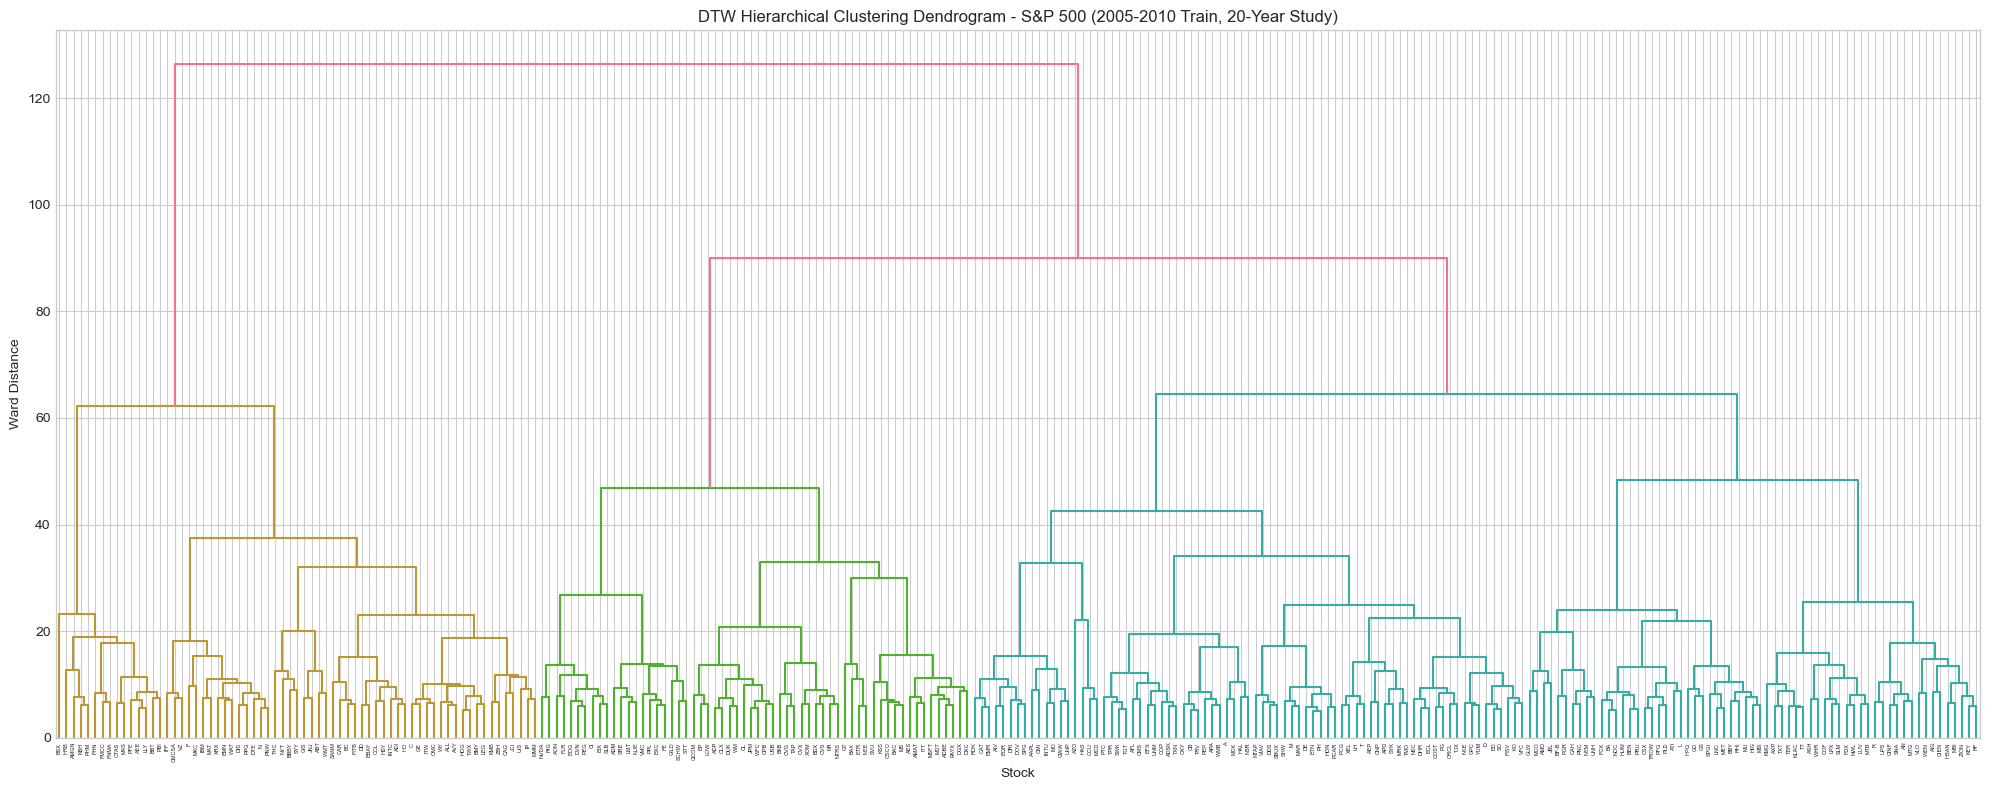


DTW cluster assignments saved to dtw_cluster_df and dtw_cluster_assignments_sp500_20y.csv
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           2           3           5
1   AAPL           2           3           5
2    ABT           1           1           2
3   ADBE           2           2           4
4    ADI           1           1           2


In [7]:
# DTW hierarchical clustering (k=2, 4, 7), Ward linkage
condensed_dtw = squareform(dtw_distance_matrix)
dtw_linkage = linkage(condensed_dtw, method='ward')

dtw_clusters = {}
for k in K_VALUES:
    dtw_clusters[k] = fcluster(dtw_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(dtw_clusters[k]).value_counts().sort_index()
    print(f'k={k}: cluster sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(dtw_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('DTW Hierarchical Clustering Dendrogram - S&P 500 (2005-2010 Train, 20-Year Study)')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dtw_dendrogram_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing cluster assignments in a DataFrame for later use (cointegration testing)
dtw_clusters_df = pd.DataFrame({'ticker':tickers})
for k in K_VALUES:
    dtw_clusters_df[f'cluster_k{k}'] = dtw_clusters[k]

dtw_clusters_df.to_csv('dtw_cluster_assignments_sp500_20y.csv', index=False)

print(f'\nDTW cluster assignments saved to dtw_cluster_df and dtw_cluster_assignments_sp500_20y.csv')
print(dtw_clusters_df.head())

In [8]:
# Cluster validation indices for DTW clustering
dtw_cvi_results = []

for k in K_VALUES:
    labels = dtw_clusters[k]

    # Silhouette score using DTW distance matrix directly
    sil = silhouette_score(dtw_distance_matrix, labels, metric='precomputed')

    # Calinski-Harabasz and Davies-Bouldin using raw Sharpe ratio scores
    ch = calinski_harabasz_score(train_sharpe_data.T, labels)
    db = davies_bouldin_score(train_sharpe_data.T, labels)

    dtw_cvi_results.append({
        'k': k,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })

    print(f'k={k}: silhouette={sil:.4f}, calinski_harabasz={ch:.2f}, davies_bouldin={db:.4f}')

dtw_cvi_df = pd.DataFrame(dtw_cvi_results)
print('\nDTW Cluster Validation Summary:')
print(dtw_cvi_df)   

k=2: silhouette=0.2113, calinski_harabasz=27.53, davies_bouldin=2.5727
k=4: silhouette=0.1180, calinski_harabasz=22.13, davies_bouldin=2.7211
k=7: silhouette=0.0984, calinski_harabasz=16.18, davies_bouldin=2.7152

DTW Cluster Validation Summary:
   k  silhouette  calinski_harabasz  davies_bouldin
0  2      0.2113            27.5324          2.5727
1  4      0.1180            22.1262          2.7211
2  7      0.0984            16.1798          2.7152


In [9]:
# OCP (Optimal Causal Path) distance function

def ocp_distance(x, y):
    """
    Computes the Optimal Causal Path between two time series,
    by enforcing a causality constaint where j >= i, blocking
    the lower triangle of the cost matrix. This prevents a 
    future observation of x from being matches to a past 
    observation in y, one directional assumption of the lead-lag
    relationship rather than a determination of it.
    """
    n, m = len(x), len(y)
    cost = np.full ((n,m), np.inf)
    cost[0,0] = abs(x[0] - y[0])

    for i in range(n):
        for j in range(m):
            if j < i:
                continue
            if i == 0 and j == 0:
                continue
            candidates = []
            if i > 0:
                candidates.append(cost[i - 1, j])
            if j > 0:
                candidates.append(cost[i, j - 1])
            if i > 0 and j > 0:
                candidates.append(cost[i - 1, j - 1])
            cost[i, j] = abs(x[i] - y[j]) + min(candidates)

    return cost[n - 1, m -1]

def ocp_symmetric(x, y):
    """
    Computes OCP distance in both directions and takes the minimum, 
    improving on Stubinger (2019) who assumes a fixed lead direction.
    """
    return min(ocp_distance(x,y), ocp_distance(y,x))
    

In [10]:
!pip install multiprocess

In [11]:
from multiprocess import Pool

def ocp_pair_worker(args):
    import numpy as np

    def _ocp_distance(x,y):
         n, m = len(x), len(y)
         cost = np.full ((n,m), np.inf)
         cost[0,0] = abs(x[0] - y[0])
         for i in range(n):
            for j in range(m):
                if j < i:
                    continue
                if i == 0 and j == 0:
                    continue
                candidates = []
                if i > 0:
                    candidates.append(cost[i - 1, j])
                if j > 0:
                    candidates.append(cost[i, j - 1])
                if i > 0 and j > 0:
                    candidates.append(cost[i - 1, j - 1])
                cost[i, j] = abs(x[i] - y[j]) + min(candidates)
         return cost[n - 1, m -1]

    i, j, x, y = args
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    d = min(_ocp_distance(x,y), _ocp_distance(y,x))
    return i, j, d

tickers = train_sharpe_data.columns.tolist()
n = len(tickers)

tasks = []
for i in range(n):
    for j in range(i + 1, n):
        x = train_sharpe_data.iloc[:, i].values
        y = train_sharpe_data.iloc[:, j].values
        tasks.append((i , j, x, y))

print(f'Total pairs to compute: {len(tasks)}')
print(f'Using {N_CORES} cores')

start_time = time.time()
ocp_matrix = np.zeros((n,n))

with Pool(processes=N_CORES) as pool:
    completed = 0
    for i, j, d in pool.imap_unordered(ocp_pair_worker, tasks, chunksize=50):
        ocp_matrix[i,j] = d
        ocp_matrix[j,i] = d
        completed += 1
        if completed % 5000 == 0:
            elapsed = time.time() - start_time
            pct = completed / len(tasks) * 100
            eta = (elapsed / completed) * (len(tasks) - completed)
            print(f' {completed:,}/{len(tasks):,} ({pct:.1f}%) - elapsed {elapsed:0f}s - ETA {eta:.0f}s')
        if completed % 10000 == 0:
            np.save('ocp_distance_matrix_sp500_20y_checkpoint.npy', ocp_matrix)
            print(f'  [checkpoint saved at {completed:,} pairs]')

elapsed = time.time() - start_time
print(f'\nOCP distance matrix computed in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)')
print(f'Matrix shape: {ocp_matrix.shape}')

# Saving the results to disk
np.save('ocp_distance_matrix_sp500_20y_train.npy', ocp_matrix)
pd.Series(tickers).to_csv('ocp_tickers_sp500_20y_train.csv', index=False)
train_sharpe_data.to_csv('ocp_sharpe_data_sp500_20y_train.csv')
print('\nSaved: ocp_distance_matrix_sp500_20y_train.npy, ocp_tickers_sp500_20y_train.csv, ocp_sharpe_data_sp500_20y_train.csv')


Total pairs to compute: 35511
Using 10 cores
 5,000/35,511 (14.1%) - elapsed 53.398628s - ETA 326s
 10,000/35,511 (28.2%) - elapsed 106.996929s - ETA 273s
  [checkpoint saved at 10,000 pairs]
 15,000/35,511 (42.2%) - elapsed 160.024658s - ETA 219s
 20,000/35,511 (56.3%) - elapsed 211.580621s - ETA 164s
  [checkpoint saved at 20,000 pairs]
 25,000/35,511 (70.4%) - elapsed 262.612510s - ETA 110s
 30,000/35,511 (84.5%) - elapsed 315.834809s - ETA 58s
  [checkpoint saved at 30,000 pairs]
 35,000/35,511 (98.6%) - elapsed 368.317163s - ETA 5s

OCP distance matrix computed in 372 seconds (6.2 minutes)
Matrix shape: (267, 267)

Saved: ocp_distance_matrix_sp500_20y_train.npy, ocp_tickers_sp500_20y_train.csv, ocp_sharpe_data_sp500_20y_train.csv


k=2: cluster sizes = [76, 191]
k=4: cluster sizes = [35, 41, 87, 104]
k=7: cluster sizes = [35, 41, 29, 58, 62, 19, 23]


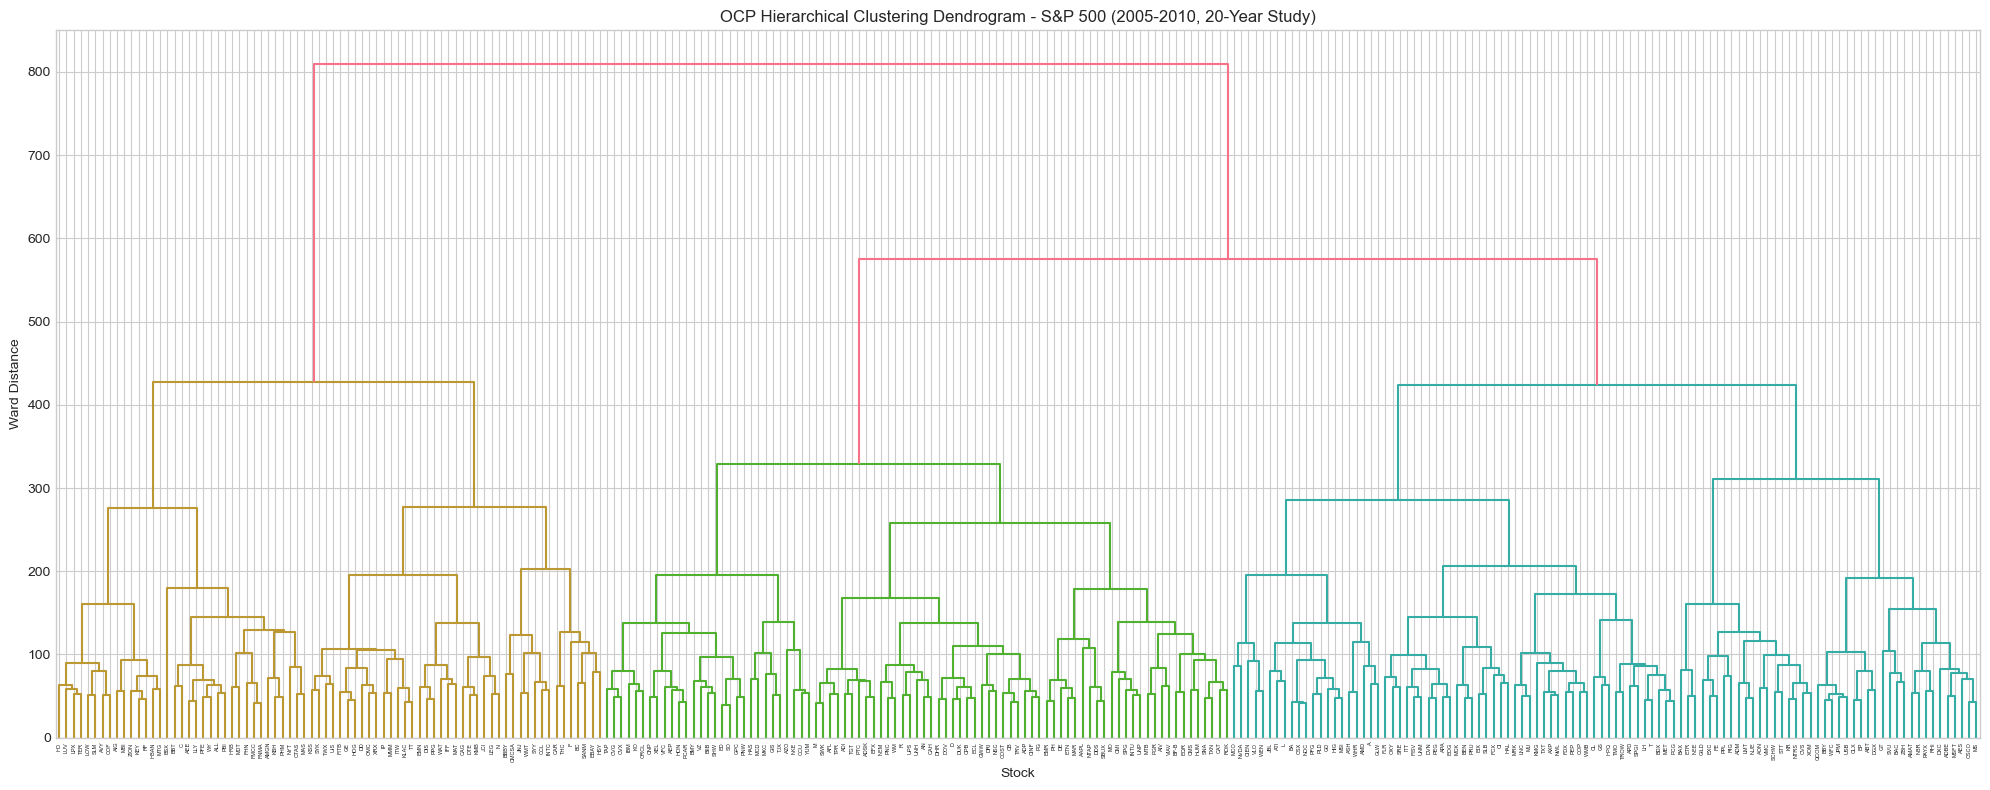


OCP cluster assignments saved to ocp_cluster_df and ocp_cluster_assignments_sp500_20y.csv
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           2           4           5
1   AAPL           2           3           4
2    ABT           2           4           7
3   ADBE           2           4           7
4    ADI           2           3           4
\OCP Cluster Validation Summary:
   k  silhouette  calinski_harabasz  davies_bouldin
0  2      0.1654            37.3271          2.3143
1  4      0.0988            23.0052          2.8889
2  7      0.0753            18.0399          2.8123


In [12]:
# OCP hierarchical clustering (k=2, 4, 7), Ward linkage
condensed_ocp = squareform(ocp_matrix)
ocp_linkage = linkage(condensed_ocp, method='ward')

ocp_clusters = {}
for k in K_VALUES:
    ocp_clusters[k] = fcluster(ocp_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(ocp_clusters[k]).value_counts().sort_index()
    print(f'k={k}: cluster sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(ocp_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('OCP Hierarchical Clustering Dendrogram - S&P 500 (2005-2010, 20-Year Study)')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('ocp_dendrogram_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing cluster assignments
ocp_cluster_df = pd.DataFrame({'ticker': tickers})
for k in K_VALUES:
    ocp_cluster_df[f'cluster_k{k}'] = ocp_clusters[k]

ocp_cluster_df.to_csv('ocp_cluster_assignments_sp500_20y.csv', index=False)

print(f'\nOCP cluster assignments saved to ocp_cluster_df and ocp_cluster_assignments_sp500_20y.csv')
print(ocp_cluster_df.head())

# Cluster validation indices
ocp_cvi_results = []

for k in K_VALUES:
    labels = ocp_clusters[k]

    sil = silhouette_score(ocp_matrix, labels, metric='precomputed')
    ch = calinski_harabasz_score(train_sharpe_data.T, labels)
    db = davies_bouldin_score(train_sharpe_data.T, labels)

    ocp_cvi_results.append({
        'k': k, 
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })

ocp_cvi_df = pd.DataFrame(ocp_cvi_results)
print('\OCP Cluster Validation Summary:')
print(ocp_cvi_df)   

In [18]:
from scipy.special import logsumexp

TOP_TEMP = 0.25 # placeholder before tuning

def top_free_energy(x, y, T=TOP_TEMP):
    """
    Computes  the TOP (Thermal Optimal Path) free energy between two time
    series, under the same causality constraint as OCP (j >= i). As T 
    shrinks closer to 0, the cost converges to OCP's cost. 
    """
    n, m = len(x), len(y)
    log_z = np.full((n, m), -np.inf)
    log_z[0,0]  = -abs(x[0] - y[0]) /  T  # log-Boltzman-weight

    for i in range(n):
        for j in range(m):
            if j < i:
                continue
            if i == 0 and j == 0:
                continue
            preds = []
            if i > 0:
                preds.append(log_z[i - 1, j])
            if j >  0:
                preds.append(log_z[i, j - 1])
            if i > 0 and j > 0:
                preds.append(log_z[i - 1, j - 1])
            local  = -abs(x[i] - y[j]) / T
            log_z[i, j] = local + logsumexp(preds)


    return -T * log_z[n - 1, m - 1]

def top_symmetric(x, y,  T=TOP_TEMP):
    """
    Computes TOP free energy in both directions and takes the minimum,
    same process as the ocp function.
    """
    return min(top_free_energy(x, y, T), top_free_energy(y, x, T))

In [20]:
def top_pair_worker(args):
    import numpy as np
    import math

    def _logsumexp_small(vals):
        m = max(vals)
        if m == -math.inf:
            return -math.inf
        total = 0.0
        for v in vals:
            total += math.exp(v - m)
        return m + math.log(total)

    def top_free_energy(x, y, T):
        m, n = len(x), len(y)
        log_z = np.full((m, n), -np.inf)
        log_z[0, 0] = -abs(x[0] - y[0]) / T
        for ii in range(m):
            for jj in range(n):
                if ii == 0 and jj == 0:
                    continue
                if jj < ii:
                    continue
                preds = []
                if ii > 0:
                    preds.append(log_z[ii - 1, jj])
                if jj > 0:
                    preds.append(log_z[ii, jj - 1])
                if ii > 0 and jj > 0:
                    preds.append(log_z[ii - 1, jj - 1])
                local = -abs(x[ii] - y[jj]) / T
                log_z[ii, jj] = local + _logsumexp_small(preds)
        return -T * log_z[m - 1, n - 1]

    i, j, x, y, T = args

    d = min(
        top_free_energy(x, y, T),
        top_free_energy(y, x, T)
    )

    return i, j, d

tickers = train_sharpe_data.columns.tolist()
n = len(tickers)

tasks = []
for i in range(n):
    for j in range(i + 1, n):
        x = train_sharpe_data.iloc[:, i].values
        y = train_sharpe_data.iloc[:, j].values
        tasks.append((i, j, x, y, TOP_TEMP))

print(f'Total pairs to compute: {len(tasks)}')
print(f'Using {N_CORES} cores, T={TOP_TEMP}')

start_time = time.time()
top_matrix = np.zeros((n, n))

with Pool(processes=N_CORES) as pool:
    completed = 0
    for i, j, d in pool.imap_unordered(top_pair_worker, tasks, chunksize=50):
        top_matrix[i,j] = d
        top_matrix[j,i] = d
        completed += 1
        if completed % 5000 == 0:
            elapsed = time.time() - start_time
            pct = completed / len(tasks) * 100
            eta = (elapsed / completed) * (len(tasks) - completed)
            print(f' {completed:,}/{len(tasks):,} ({pct:.1f}%) - elapsed {elapsed:0f}s - ETA {eta:.0f}s')
        if completed % 10000 == 0:
            np.save('top_distance_matrix_sp500_20y_checkpoint.npy', top_matrix)
            print(f'  [checkpoint saved at {completed:,} pairs]')

elapsed = time.time() - start_time
print(f'\nTOP distance matrix computed in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)')
print(f'Matrix shape: {top_matrix.shape}')

# Shifting the matrix to eliminate negative free-energy values
min_val = top_matrix.min()
n_negative_pairs = np.sum(top_matrix < 0) // 2 # halving the count due to matrix similarity

if min < 0:
    shift = abs(min_val)
    top_matrix = top_matrix + shift
    np.fill_diagonal(top_matrix, 0) # keeps diagonal values 0 after the shift
    print(f'\Shifted TOP matrix by +{shift:.4f} to eliminate {n_negative_pairs} negative pairs')
    print(f'New min: {top_matrix.min():.4f}, new max: {top_matrix.max():.4f}')
else:
    print(f'\nNo negative values found -- no shift needed')

# Saving the results to disk
np.save('top_distance_matrix_sp500_20y_train.npy', top_matrix)
pd.Series(tickers).to_csv('top_tickers_sp500_20y_train.csv', index=False)
print('\nSaved: top_distance_matrix_sp500_20y_train.npy, top_tickers_sp500_20y_train.csv, top_sharpe_data_sp500_20y_train.csv')        

Total pairs to compute: 35511
Using 10 cores, T=0.25
 5,000/35,511 (14.1%) - elapsed 99.029016s - ETA 604s
 10,000/35,511 (28.2%) - elapsed 196.270690s - ETA 501s
  [checkpoint saved at 10,000 pairs]
 15,000/35,511 (42.2%) - elapsed 291.600195s - ETA 399s
 20,000/35,511 (56.3%) - elapsed 386.946261s - ETA 300s
  [checkpoint saved at 20,000 pairs]
 25,000/35,511 (70.4%) - elapsed 484.751674s - ETA 204s
 30,000/35,511 (84.5%) - elapsed 580.714787s - ETA 107s
  [checkpoint saved at 30,000 pairs]
 35,000/35,511 (98.6%) - elapsed 675.918625s - ETA 10s

TOP distance matrix computed in 683 seconds (11.4 minutes)
Matrix shape: (267, 267)


TypeError: '<' not supported between instances of 'builtin_function_or_method' and 'int'

In [21]:
min_val = top_matrix.min()
n_negative_pairs = np.sum(top_matrix < 0) // 2

if min_val < 0:
    shift = abs(min_val)
    top_matrix = top_matrix + shift
    np.fill_diagonal(top_matrix, 0)
    print(f'\nShifted TOP matrix by +{shift:.4f} to eliminate {n_negative_pairs} negative pairs')
    print(f'New min: {top_matrix.min():.4f}, new max: {top_matrix.max():.4f}')
else:
    print(f'\nNo negative values found -- no shift needed')

np.save('top_distance_matrix_sp500_20y_train.npy', top_matrix)
pd.Series(tickers).to_csv('top_tickers_sp500_20y_train.csv', index=False)
train_sharpe_data.to_csv('top_sharpe_data_sp500_20y_train.csv')
print('\nSaved: top_distance_matrix_sp500_20y_train.npy, top_tickers_sp500_20y_train.csv, top_sharpe_data_sp500_20y_train.csv')


Shifted TOP matrix by +19.9481 to eliminate 213 negative pairs
New min: 0.0000, new max: 471.5937

Saved: top_distance_matrix_sp500_20y_train.npy, top_tickers_sp500_20y_train.csv, top_sharpe_data_sp500_20y_train.csv


In [22]:
print(pd.DataFrame(top_matrix[:5,:5], index=tickers[:5], columns=tickers[:5]))

            A     AAPL      ABT     ADBE      ADI
A      0.0000 140.2222 152.4418  48.6508  56.9768
AAPL 140.2222   0.0000 211.9567 161.9149 182.8972
ABT  152.4418 211.9567   0.0000  71.6136  85.1571
ADBE  48.6508 161.9149  71.6136   0.0000  67.0564
ADI   56.9768 182.8972  85.1571  67.0564   0.0000


k=2: cluster sizes = [78, 189]
k=4: cluster sizes = [32, 46, 31, 158]
k=7: cluster sizes = [32, 28, 18, 31, 54, 31, 73]


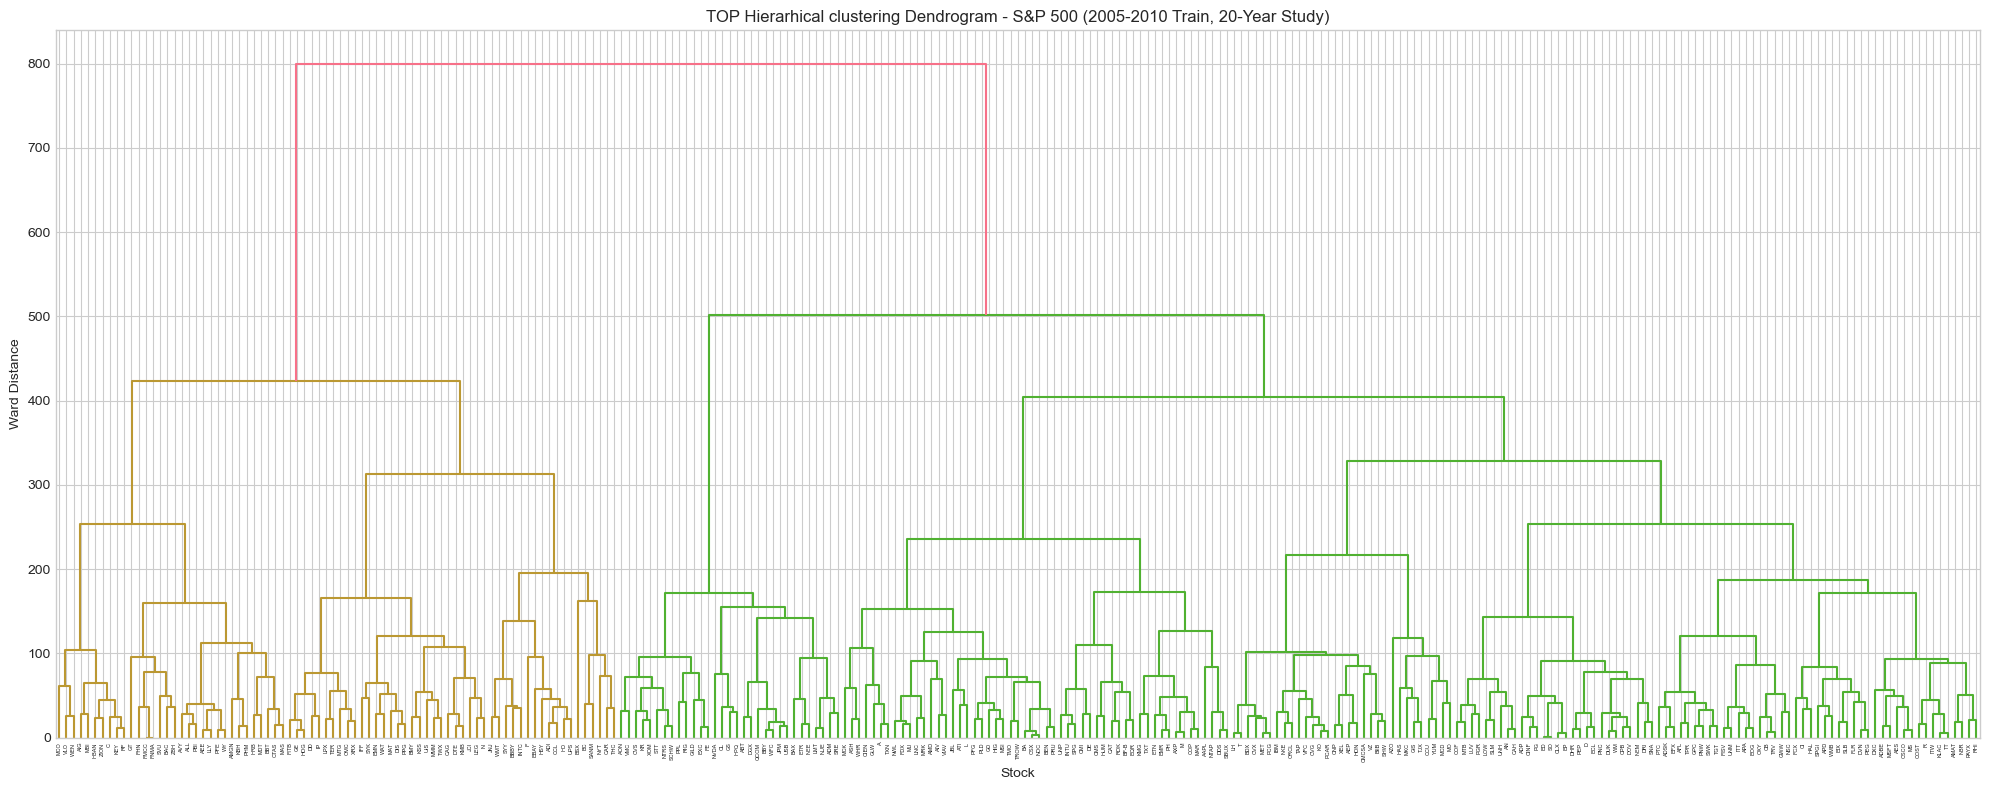


TOP cluster assignments saved to top_cluster_df and top_cluster_assignments_sp500_20y.csv
  ticker  cluster_k2  cluster_k4  cluster_k7
0      A           2           4           5
1   AAPL           2           4           5
2    ABT           2           3           4
3   ADBE           2           4           7
4    ADI           1           2           3
k=2: silhouette=0.2324, calinski_harabasz=36.63, davies_bouldin=2.3704
k=4: silhouette=0.1654, calinski_harabasz=22.14, davies_bouldin=2.4577
k=7: silhouette=0.1215, calinski_harabasz=18.02, davies_bouldin=2.6994

TOP Cluster Validation Summary:
   k  silhouette  calinski_harabasz  davies_bouldin
0  2      0.2324            36.6349          2.3704
1  4      0.1654            22.1431          2.4577
2  7      0.1215            18.0185          2.6994


In [23]:
# TOP hierarchical clustering (k=2, 4, 7), Ward linkage
condensed_top = squareform(top_matrix)
top_linkage = linkage(condensed_top, method='ward')

top_clusters = {}
for k in K_VALUES:
    top_clusters[k] = fcluster(top_linkage, t=k, criterion='maxclust')
    sizes = pd.Series(top_clusters[k]).value_counts().sort_index()
    print(f'k={k}: cluster sizes = {sizes.tolist()}')

# Dendrogram
fig, ax = plt.subplots(figsize=(20,8))
dendrogram(top_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=4, ax=ax)
ax.set_title('TOP Hierarhical clustering Dendrogram - S&P 500 (2005-2010 Train, 20-Year Study)')
ax.set_xlabel('Stock')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('top_dendrogram_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

# Storing cluster assignments
top_cluster_df = pd.DataFrame({'ticker': tickers})
for k in K_VALUES:
    top_cluster_df[f'cluster_k{k}'] = top_clusters[k]

top_cluster_df.to_csv('top_cluster_assignments_sp500_20y.csv', index=False)

print(f'\nTOP cluster assignments saved to top_cluster_df and top_cluster_assignments_sp500_20y.csv')
print(top_cluster_df.head())

# Cluster validation indices
top_cvi_results = []

for k in K_VALUES:
    labels = top_clusters[k]

    sil = silhouette_score(top_matrix, labels, metric='precomputed')
    ch = calinski_harabasz_score(train_sharpe_data.T, labels)
    db = davies_bouldin_score(train_sharpe_data.T, labels)

    top_cvi_results.append({
        'k': k,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })

    print(f'k={k}: silhouette={sil:.4f}, calinski_harabasz={ch:.2f}, davies_bouldin={db:.4f}')

top_cvi_df = pd.DataFrame(top_cvi_results)
print('\nTOP Cluster Validation Summary:')
print(top_cvi_df)

k=2: DTW-OCP=0.6179, DTW-TOP=0.6192, OCP-TOP=0.7395
k=4: DTW-OCP=0.2976, DTW-TOP=0.2601, OCP-TOP=0.3479
k=7: DTW-OCP=0.3131, DTW-TOP=0.2015, OCP-TOP=0.3302

Pairwise Agreement Summary (Adjusted Rand Index):
   k  DTW_vs_OCP  DTW_vs_TOP  OCP_vs_TOP
0  2      0.6179      0.6192      0.7395
1  4      0.2976      0.2601      0.3479
2  7      0.3131      0.2015      0.3302


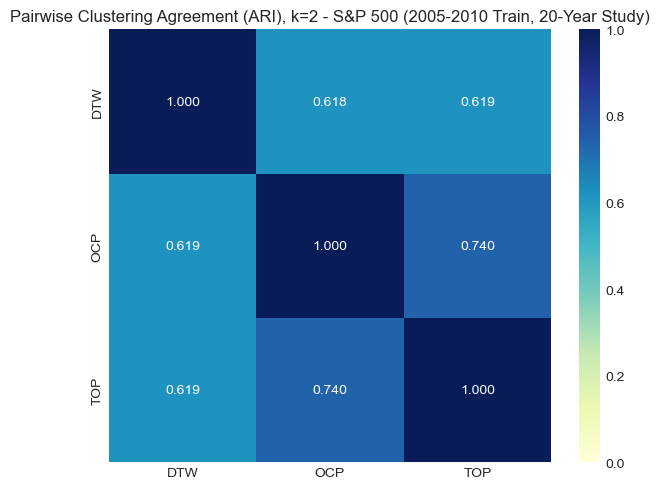


Saved: pairwise_ari_heatmap_sp500_20y.png, pairwise_ari_sp500_20y.csv


In [24]:
# Pairwise agreement between DTW, OCP, and TOP clusterings (Ajusted Rand Index)

ari_results = []

for k in K_VALUES:
    dtw_labels = dtw_clusters[k]
    ocp_labels = ocp_clusters[k]
    top_labels = top_clusters[k]

    ari_dtw_ocp = adjusted_rand_score(dtw_labels, ocp_labels)
    ari_dtw_top = adjusted_rand_score(dtw_labels, top_labels)
    ari_ocp_top = adjusted_rand_score(ocp_labels, top_labels)

    ari_results.append({
        'k': k,
        'DTW_vs_OCP': ari_dtw_ocp,
        'DTW_vs_TOP': ari_dtw_top,
        'OCP_vs_TOP': ari_ocp_top
    })

    print(f'k={k}: DTW-OCP={ari_dtw_ocp:.4f}, DTW-TOP={ari_dtw_top:.4f}, OCP-TOP={ari_ocp_top:.4f}')

ari_df = pd.DataFrame(ari_results)
print('\nPairwise Agreement Summary (Adjusted Rand Index):')
print(ari_df)

# Heatmap for paper (k=2 specifically, since that's the CVI-preferred k)
fig, ax = plt.subplots(figsize=(6,5))
k2_row = ari_df[ari_df['k'] == 2].iloc[0]
agreement_matrix = pd.DataFrame(
    [[1.0, k2_row['DTW_vs_OCP'], k2_row['DTW_vs_TOP']],
     [k2_row['DTW_vs_TOP'], 1.0, k2_row['OCP_vs_TOP']],
     [k2_row['DTW_vs_TOP'], k2_row['OCP_vs_TOP'], 1.0]],
    index=['DTW', 'OCP', 'TOP'], columns=['DTW', 'OCP', 'TOP']
)
sns.heatmap(agreement_matrix,  annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1, ax=ax)
ax.set_title('Pairwise Clustering Agreement (ARI), k=2 - S&P 500 (2005-2010 Train, 20-Year Study)')
plt.tight_layout()
plt.savefig('pairwise_ari_heatmap_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

ari_df.to_csv('pairwise_ari_sp500_20y.csv', index=False)
print('\nSaved: pairwise_ari_heatmap_sp500_20y.png, pairwise_ari_sp500_20y.csv')

In [34]:
# Cointegration testing within clusters (Engle-Granger + BH correction)
from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests

train_price_data = price_data.loc[TRAIN_START:TRAIN_END]

def test_cointegration_within_clusters(clusters_df, price_data, method_name, k_col='cluster_k7', alpha=0.05):
    """
    Runs Engle-Granger cointegration tests on every pair of stocks within
    the same cluster, then applies Benjamini-Hochberg correction across
    all tests run for this method to control the false discovery rate.
    """
    results = []

    for cluster_id in sorted(clusters_df[k_col].unique()):
        cluster_tickers = clusters_df[clusters_df[k_col] == cluster_id]['ticker'].tolist()

        if len(cluster_tickers) < 2:
            continue

        for i in range(len(cluster_tickers)):
            for j in range(i + 1, len(cluster_tickers)):
                t1, t2 = cluster_tickers[i], cluster_tickers[j]

                if t1 not in price_data.columns or t2 not in price_data.columns:
                    continue

                series1 = np.log(price_data[t1])
                series2 = np.log(price_data[t2])

                score, pvalue, _ = coint(series1, series2)

                results.append({
                    'method': method_name,
                    'cluster': cluster_id,
                    'stock1': t1,
                    'stock2': t2,
                    'coint_value': pvalue
                })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        rejected, pvals_corrected, _, _ = multipletests(results_df['coint_value'], alpha=alpha, method='fdr_bh')
        results_df['pvalue_bh_corrected'] = pvals_corrected
        results_df['significant'] = rejected

    print(f'{method_name}: {len(results_df)} pairs tested, {results_df['significant'].sum() if len(results_df) > 0 else 0} significant after BH correction')

    return results_df

dtw_coint_results = test_cointegration_within_clusters(dtw_clusters_df, train_price_data, 'DTW')
ocp_coint_results = test_cointegration_within_clusters(ocp_cluster_df, train_price_data, 'OCP')
top_coint_results = test_cointegration_within_clusters(top_cluster_df, train_price_data, 'TOP')

all_coint_results = pd.concat([dtw_coint_results, ocp_coint_results, top_coint_results], ignore_index=True)
all_coint_results.to_csv('coint_results_all_methods_sp500_20y_train.csv', index=False)

print(f'\nTotal candidate pairs across all method: {all_coint_results['significant'].sum()}')
print(all_coint_results[all_coint_results['significant']].sort_values('pvalue_bh_corrected').head(10))            

DTW: 6271 pairs tested, 17 significant after BH correction
OCP: 5789 pairs tested, 20 significant after BH correction
TOP: 6016 pairs tested, 16 significant after BH correction

Total candidate pairs across all method: 53
      method  cluster stock1 stock2  coint_value  pvalue_bh_corrected  \
1428     DTW        2     WY    XRX       0.0000               0.0009   
9664     OCP        4    ROK    UPS       0.0000               0.0037   
6741     OCP        1    LLY     RF       0.0000               0.0041   
12458    TOP        1    LLY     RF       0.0000               0.0086   
6562     OCP        1   CTAS    SLM       0.0000               0.0104   
6638     OCP        1   HBAN    KEY       0.0000               0.0167   
6556     OCP        1   CTAS    MTG       0.0000               0.0167   
6751     OCP        1    LOW    MTG       0.0000               0.0167   
6652     OCP        1   HBAN    SLM       0.0000               0.0167   
8036     OCP        3    NKE    YUM       0.0000

In [37]:
!pip install pykalman


   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 2/2 [pykalman]



In [38]:
# Kalman filter hedge ratio estimation for cointegrated pairs
from pykalman import KalmanFilter

significant_pairs = all_coint_results[all_coint_results['significant']].reset_index(drop=True)
print(f'Fitting Kalman filters for {len(significant_pairs)} significant pairs...')

kalman_results = {}

for idx, row in significant_pairs.iterrows():
    method, s1, s2 = row['method'], row['stock1'], row['stock2']

    y = np.log(train_price_data[s1].values)
    x = np.log(train_price_data[s2].values)

    # Observation matrix [x_t, 1]
    obs_matrix = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

    kf = KalmanFilter(
        n_dim_obs =1, 
        n_dim_state=2,
        initial_state_mean=[0,0],
        initial_state_covariance=np.ones((2,2)),
        transition_matrices=np.eye(2),
        observation_matrices=obs_matrix,
        observation_covariance=1.0,
        transition_covariance=1e-5 * np.eye(2)
    )

    state_means, state_covariance = kf.filter(y)

    hedge_ratio = state_means[:,0]
    intercept = state_means[:,1]

    spread = y - hedge_ratio * x - intercept

    kalman_results[(method, s1, s2)] = {
        'hedge_ratio': hedge_ratio,
        'intercept': intercept,
        'spread': spread
    }

    if idx < 3 or idx == len(significant_pairs) - 1:
        print(f' {method} {s1}-{s2}: hedge_ratio range [{hedge_ratio.min():.3f}, {hedge_ratio.max():.3f}], mean  spread {spread.mean():.4f}')

print(f'\nKalman filters fitted for all {len(kalman_results)} pairs')

import pickle
with open('kalman_results_sp500_20y_train.pkl',  'wb') as f:
    pickle.dump(kalman_results, f)
print('Saved: kalman_results_sp500_20y_train.pkl') 

Fitting Kalman filters for 53 significant pairs...
 DTW AVY-WY: hedge_ratio range [0.941, 1.026], mean  spread 0.0006
 DTW CCL-EBAY: hedge_ratio range [0.854, 1.012], mean  spread 0.0680
 DTW WY-XRX: hedge_ratio range [0.595, 0.660], mean  spread -0.0129
 TOP ADSK-EFX: hedge_ratio range [0.778, 0.841], mean  spread -0.0440

Kalman filters fitted for all 53 pairs
Saved: kalman_results_sp500_20y_train.pkl


In [42]:
# Regime detection: classifying high/low volatility periods per pair's spread

regime_results = {}

for key, kr in kalman_results.items():
    method, s1, s2 = key
    spread = kr['spread']

    spread_series = pd.Series(spread, index=train_price_data.index)

    rolling_vol = spread_series.rolling(window=VOL_WINDOW).std()

    median_vol = rolling_vol.median()

    regime = pd.Series('normal', index=spread_series.index)
    regime[rolling_vol > median_vol * VOL_THRESHOLD] = 'high_vol'
    regime[rolling_vol < median_vol / VOL_THRESHOLD] = 'low_vol'

    regime_results[key] = {
        'rolling_vol': rolling_vol,
        'regime': regime
    }

    if list(kalman_results.keys()).index(key) < 3:
        counts = regime.value_counts()
        print(f'  {method} {s1}-{s2}: {dict(counts)}')

print(f'\nRegime classification complete for all {len(regime_results)} pairs')

import pickle
with open('regime_results_sp500_20y_train.pkl', 'wb') as f:
    pickle.dump(regime_results, f)
print('Saved: regime_results_sp500_20y_train.pkl')

  DTW AVY-WY: {'normal': np.int64(222), 'high_vol': np.int64(59), 'low_vol': np.int64(32)}
  DTW CCL-EBAY: {'normal': np.int64(248), 'low_vol': np.int64(43), 'high_vol': np.int64(22)}
  DTW WY-XRX: {'normal': np.int64(167), 'high_vol': np.int64(81), 'low_vol': np.int64(65)}

Regime classification complete for all 53 pairs
Saved: regime_results_sp500_20y_train.pkl


In [43]:
# Z-score signal generation with regime-dependent thresholds 

signal_results = {}

for key in kalman_results.keys():
    method, s1, s2 = key
    spread = kalman_results[key]['spread']
    regime = regime_results[key]['regime']

    spread_series = pd.Series(spread,  index=train_price_data.index)

    rolling_mean = spread_series.rolling(window=ZSCORE_WINDOW).mean()
    rolling_std = spread_series.rolling(window=ZSCORE_WINDOW).std()
    zscore = (spread_series - rolling_mean) / rolling_std

    entry_threshold = pd.Series(STANDARD_ENTRY, index=zscore.index)
    entry_threshold[regime == 'high_vol'] = HIGH_VOL_ENTRY
    entry_threshold[regime == 'low_vol'] = LOW_VOL_ENTRY

    signal = pd.Series(0, index=zscore.index)
    position = 0

    for t in range(len(zscore)):
        z = zscore.iloc[t]
        entry_thresh = entry_threshold.iloc[t]

        if pd.isna(z):
            signal.iloc[t] = position
            continue

        if position == 0:
            if z > entry_thresh:
                position = -1
            elif z < -entry_thresh:
                position = 1
        elif position == 1:
            if z > -EXIT_THRESHOLD or z < -STOP_LOSS:
                position = 0
        elif position == -1:
            if z < EXIT_THRESHOLD or z > STOP_LOSS:
                position = 0

        signal.iloc[t] = position

    signal_results[key] = {
        'zscore': zscore,
        'entry_threshold': entry_threshold,
        'signal': signal
    }

    if list(kalman_results.keys()).index(key) < 3:
        n_trades  = (signal.diff().abs() > 0).sum()
        print(f'  {method} {s1}-{s2}: {n_trades} position changes, signal distribution  {dict(signal.value_counts())}')

print(f'\nSignal generation complete for all {len(signal_results)} pairs')

import pickle
with open('signal_results_sp500_20y_train.pkl', 'wb') as f:
    pickle.dump(signal_results, f)
print('Saved: signal_results_sp500_20y_train.pkl')

  DTW AVY-WY: 22 position changes, signal distribution  {0: np.int64(211), -1: np.int64(54), 1: np.int64(48)}
  DTW CCL-EBAY: 22 position changes, signal distribution  {0: np.int64(206), -1: np.int64(58), 1: np.int64(49)}
  DTW WY-XRX: 24 position changes, signal distribution  {0: np.int64(236), 1: np.int64(58), -1: np.int64(19)}

Signal generation complete for all 53 pairs
Saved: signal_results_sp500_20y_train.pkl


In [47]:
print("""
    Backtesting DTW/OCP/TOP pairs: This performance-based backtest 
    is being constructed as a sanity check, rather than data that will
    be entered into the results of the final paper. The results will 
    indicate whether the pipeline worked correctly, and if the 
    Kalman filter, regime & z-score construction are safe to
    push forward to the Validation and Test periods.
""")

def compute_backtest_metrics(returns_series, rf_annual=RISK_FREE_RATE):
    """
    Computes standard backtest metrics from a weekly return series.
    """
    returns_series = returns_series.dropna()

    cumulative = returns_series.cumsum()
    total_return = cumulative.iloc[-1] if len(cumulative) > 0 else 0.0

    weekly_rf = rf_annual / 52
    excess_returns = returns_series - weekly_rf
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(52) if excess_returns.std() > 0 else 0.0

    running_max = cumulative.cummax()
    drawdown = cumulative - running_max
    max_drawdown = drawdown.min()

    n_trades = (returns_series != 0).sum()
    win_rate = (returns_series > 0).sum() / n_trades if n_trades > 0 else 0

    return {
        'total_return': total_return,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_active_weeks': n_trades
    }

pair_backtest_results = {}

for key in signal_results.keys():
    method, s1, s2 = key
    spread = kalman_results[key]['spread']
    signal = signal_results[key]['signal']

    spread_series = pd.Series(spread, index=train_price_data.index)
    spread_diff = spread_series.diff()

    # Lagging the signal by one period to avoid look-ahead bias
    pair_returns = signal.shift(1)  * spread_diff
    pair_backtest_results[key] = {
        'returns': pair_returns,
        'metrics': compute_backtest_metrics(pair_returns)
    }

method_portfolio_results = {}

for method in ['DTW', 'OCP', 'TOP']:
    method_pairs = [k for k in pair_backtest_results.keys() if k[0] == method]

    if not method_pairs:
        continue

    # Equal-weighted portfolio: average return across all this method's significant pairs at each time step
    method_returns_df = pd.concat(
        [pair_backtest_results[k]['returns'] for k in method_pairs], axis=1
    )
    portfolio_returns = method_returns_df.mean(axis=1)

    method_portfolio_results[method] = {
        'returns': portfolio_returns,
        'metrics': compute_backtest_metrics(portfolio_returns),
        'n_pairs': len(method_pairs)
    }

    m = method_portfolio_results[method]['metrics']
    print(f'{method} ({len(method_pairs)} pairs): total_return={m['total_return']:.4f}, '
          f'sharpe={m['sharpe']:.3f}, max_drawdown={m['max_drawdown']:.4f}, win_rate={m['win_rate']:.3f}')

import pickle
with open('backtest_results_sp500_20y_train.pkl', 'wb') as f:
    pickle.dump({'pairs': pair_backtest_results, 'portfolios': method_portfolio_results}, f)
print('\nSaved: backtest_results_sp500_20y_train.pkl')


    Backtesting DTW/OCP/TOP pairs: This performance-based backtest 
    is being constructed as a sanity check, rather than data that will
    be entered into the results of the final paper. The results will 
    indicate whether the pipeline worked correctly, and if the 
    Kalman filter, regime & z-score construction are safe to
    push forward to the Validation and Test periods.

DTW (17 pairs): total_return=0.9121, sharpe=0.977, max_drawdown=-0.0787, win_rate=0.617
OCP (20 pairs): total_return=0.8353, sharpe=0.770, max_drawdown=-0.1053, win_rate=0.577
TOP (16 pairs): total_return=0.7635, sharpe=0.772, max_drawdown=-0.1461, win_rate=0.571

Saved: backtest_results_sp500_20y_train.pkl


In [49]:
# Extending the Kalman filter continuously through Validation

train_val_price_data = price_data.loc[TRAIN_START:VAL_END]

kalman_results_train_val = {}

for key in kalman_results.keys():
    method, s1, s2 = key

    y = np.log(train_val_price_data[s1].values)
    x = np.log(train_val_price_data[s2].values)

    obs_matrix = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis,:]

    kf = KalmanFilter(
        n_dim_obs =1, 
        n_dim_state=2,
        initial_state_mean=[0,0],
        initial_state_covariance=np.ones((2,2)),
        transition_matrices=np.eye(2),
        observation_matrices=obs_matrix,
        observation_covariance=1.0,
        transition_covariance=1e-5 * np.eye(2)
    )

    state_means, state_covariance = kf.filter(y)

    hedge_ratio = state_means[:,0]
    intercept = state_means[:,1]

    spread = y - hedge_ratio * x - intercept

    kalman_results_train_val[key] = {
        'hedge_ratio': hedge_ratio,
        'intercept': intercept,
        'spread': spread,
        'dates': train_val_price_data.index
    }

print(f'Continuous Train+Validation filter fitted for all {len(kalman_results_train_val)} pairs')
print(f'Combined window: {train_val_price_data.index[0].date()} to {train_val_price_data.index[-1].date()} ({len(train_val_price_data)} weeks')

import pickle
with open('kalman_results_sp500_20y_train_val.pkl', 'wb') as f:
    pickle.dump(kalman_results_train_val, f)
print('Saved: kalman_results_sp500_20y_train_val.pkl')

Continuous Train+Validation filter fitted for all 53 pairs
Combined window: 2005-01-05 to 2017-12-27 (678 weeks
Saved: kalman_results_sp500_20y_train_val.pkl


In [53]:
# Extending regime detection into Validation,  using Train's locked median_vol baseline

regime_results_train_val = {}

for key in kalman_results_train_val.keys():
    method, s1, s2 = key
    spread = kalman_results_train_val[key]['spread']
    dates = kalman_results_train_val[key]['dates']

    spread_series = pd.Series(spread, index=dates)

    rolling_vol = spread_series.rolling(window=VOL_WINDOW).std()

    train_only_vol = rolling_vol[rolling_vol.index <= TRAIN_END]
    median_vol = train_only_vol.median()

    regime = pd.Series('normal', index=spread_series.index)
    regime[rolling_vol > median_vol * VOL_THRESHOLD] = 'high_vol'
    regime[rolling_vol < median_vol / VOL_THRESHOLD] = 'low_vol'

    regime_results_train_val[key] = {
        'rolling_vol': rolling_vol,
        'regime': regime,
        'median_vol_baseline': median_vol
    }

    if list(kalman_results_train_val.keys()).index(key) < 3:
        val_regime = regime[regime.index > TRAIN_END]
        counts = val_regime.value_counts()
        print(f'  {method} {s1}-{s2}: Validation-period regime distribution {dict(counts)}')

print(f'\nRegime extension complete for all {len(regime_results_train_val)} pairs')

import pickle
with open('regime_results_sp500_20y_train_val.pkl', 'wb') as f:
    pickle.dump(regime_results_train_val, f)
print('Saved: regime_results_sp500_20y_train_val.pkl')

  DTW AVY-WY: Validation-period regime distribution {'normal': np.int64(236), 'low_vol': np.int64(109), 'high_vol': np.int64(20)}
  DTW CCL-EBAY: Validation-period regime distribution {'normal': np.int64(204), 'low_vol': np.int64(139), 'high_vol': np.int64(22)}
  DTW WY-XRX: Validation-period regime distribution {'normal': np.int64(213), 'high_vol': np.int64(82), 'low_vol': np.int64(70)}

Regime extension complete for all 53 pairs
Saved: regime_results_sp500_20y_train_val.pkl


In [63]:
# Validation threshold: selecting an entry-threshold multiplier by pooled Sharpe across DTW/OCP/TOP
# subject  to  a 50% activity floor

candidate_multipliers = [0.75, 0.85, 1.0, 1.15, 1.25]
ACTIVITY_FLOOR = 0.50

def generate_signal_for_pair(key, multiplier, kalman_data, regime_data):
    spread = kalman_data[key]['spread']
    dates = kalman_data[key]['dates']
    regime = regime_data[key]['regime']

    spread_series = pd.Series(spread, index=dates)
    rolling_mean = spread_series.rolling(window=ZSCORE_WINDOW).mean()
    rolling_std = spread_series.rolling(window=ZSCORE_WINDOW).std()
    zscore = (spread_series - rolling_mean)/rolling_std

    entry_threshold = pd.Series(STANDARD_ENTRY * multiplier, index=zscore.index)
    entry_threshold[regime == 'high_vol'] = HIGH_VOL_ENTRY * multiplier
    entry_threshold[regime == 'low_vol']  = LOW_VOL_ENTRY * multiplier

    signal = pd.Series(0, index=zscore.index)
    position = 0

    for t in range(len(zscore)):
        z = zscore.iloc[t]
        entry_thresh = entry_threshold.iloc[t]

        if pd.isna(z):
            signal.iloc[t] = position
            continue

        if position == 0:
            if z > entry_thresh:
                position = -1
            elif z < -entry_thresh:
                position = 1
        elif position == 1:
            if z > -EXIT_THRESHOLD or z < -STOP_LOSS:
                position = 0
        elif position == -1:
            if z < EXIT_THRESHOLD or z > STOP_LOSS:
                position = 0

        signal.iloc[t] = position

    return signal

sweep_results = []

for multiplier in candidate_multipliers:
    val_pair_returns = {}

    for key in kalman_results_train_val.keys():
        method, s1, s2 = key
        spread = kalman_results_train_val[key]['spread']
        dates = kalman_results_train_val[key]['dates']

        signal = generate_signal_for_pair(key, multiplier, kalman_results_train_val,  regime_results_train_val)

        spread_series = pd.Series(spread, index=dates)
        spread_diff = spread_series.diff()
        returns = signal.shift(1) * spread_diff

        val_returns = returns[returns.index > TRAIN_END]
        val_pair_returns[key] = val_returns

    n_active = sum(1 for k, r in val_pair_returns.items()  if (r.dropna() != 0).any())
    pct_active = n_active / len(val_pair_returns)

    pooled_returns = pd.concat(list(val_pair_returns.values()), axis=1).mean(axis=1)
    pooled_retunrs = pooled_returns.dropna()
    weekly_rf = RISK_FREE_RATE / 52
    excess = pooled_returns - weekly_rf
    pooled_sharpe = (excess.mean() / excess.std()) * np.sqrt(52) if excess.std() > 0 else 0.0

    sweep_results.append({
        'multiplier': multiplier,
        'pct_active': pct_active,
        'pooled_sharpe': pooled_sharpe,
        'passes_floor': pct_active >= ACTIVITY_FLOOR
    })

    print(f'multiplier={multiplier}: {pct_active:.1%} pairs active, pooled Sharpe={pooled_sharpe:.4f}, '
          f'passes floor={pct_active >= ACTIVITY_FLOOR}')

sweep_df = pd.DataFrame(sweep_results)
print('\nThreshold Sweep Summary:')
print(sweep_df)

valid_candidates = sweep_df[sweep_df['passes_floor']]

if len(valid_candidates) == 0:
    print('\nWarning: No multiplier passed the 50% activity floor. Consider lowering the floor or widening the candidate range.')
else:
    chosen_multiplier = valid_candidates.loc[valid_candidates['pooled_sharpe'].idxmax(), 'multiplier']
    print(f'\nChosen multiplier: {chosen_multiplier} (highest pooled Sharpe among candidates passing the floor)')

sweep_df.to_csv('threshold_sweep_validation_sp500_20y.csv', index=False)
print('Saved: threshold_sweep_validation_sp500_20y.csv')              

multiplier=0.75: 100.0% pairs active, pooled Sharpe=0.3384, passes floor=True
multiplier=0.85: 100.0% pairs active, pooled Sharpe=0.2124, passes floor=True
multiplier=1.0: 100.0% pairs active, pooled Sharpe=0.2526, passes floor=True
multiplier=1.15: 100.0% pairs active, pooled Sharpe=0.2865, passes floor=True
multiplier=1.25: 100.0% pairs active, pooled Sharpe=0.2312, passes floor=True

Threshold Sweep Summary:
   multiplier  pct_active  pooled_sharpe  passes_floor
0      0.7500      1.0000         0.3384          True
1      0.8500      1.0000         0.2124          True
2      1.0000      1.0000         0.2526          True
3      1.1500      1.0000         0.2865          True
4      1.2500      1.0000         0.2312          True

Chosen multiplier: 0.75 (highest pooled Sharpe among candidates passing the floor)
Saved: threshold_sweep_validation_sp500_20y.csv


In [65]:
# Extending Kalman filter + regime + signals test into Test (locked multiplier=0.75)

CHOSEN_MULTIPLIER = 0.75

train_val_test_price_data = price_data.loc[TRAIN_START:TEST_END]

kalman_results_full = {}

for key in kalman_results.keys():
    method, s1, s2 = key

    y = np.log(train_val_test_price_data[s1].values)
    x = np.log(train_val_test_price_data[s2].values)

    obs_matrix = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis,:]

    kf = KalmanFilter(
        n_dim_obs =1, 
        n_dim_state=2,
        initial_state_mean=[0,0],
        initial_state_covariance=np.ones((2,2)),
        transition_matrices=np.eye(2),
        observation_matrices=obs_matrix,
        observation_covariance=1.0,
        transition_covariance=1e-5 * np.eye(2)
    )

    state_means, state_covariance = kf.filter(y)
    hedge_ratio = state_means[:,0]
    intercept = state_means[:,1]
    spread = y - hedge_ratio * x - intercept

    kalman_results_full[key] = {
        'hedge_ratio': hedge_ratio,
        'intercept': intercept,
        'spread': spread,
        'dates': train_val_test_price_data.index
    }

print(f'Continuous Train+Validation+Test Kalman filter fitted for all {len(kalman_results_full)} pairs')
print(f'Combined window: {train_val_test_price_data.index[0].date()} to {train_val_test_price_data.index[-1].date()} ({len(train_val_test_price_data)} weeks)')

regime_results_full = {}

for key in kalman_results_full.keys():
    method, s1, s2 = key
    spread = kalman_results_full[key]['spread']
    dates = kalman_results_full[key]['dates']

    spread_series = pd.Series(spread, index=dates)
    rolling_vol = spread_series.rolling(window=VOL_WINDOW).std()
    
    train_only_vol = rolling_vol[rolling_vol.index <= TRAIN_END]
    median_vol = train_only_vol.median()

    regime = pd.Series('normal', index=spread_series.index)
    regime[rolling_vol > median_vol * VOL_THRESHOLD] = 'high_vol'
    regime[rolling_vol < median_vol / VOL_THRESHOLD] = 'low_vol'

    regime_results_full[key] = {
        'rolling_vol': rolling_vol,
        'regime': regime,
        'median_vol_baseline': median_vol
    }

print(f'Regime extension complete for all {len(regime_results_full)} pairs')

test_pair_returns = {}

for key in kalman_results_full.keys():
    signal = generate_signal_for_pair(key, CHOSEN_MULTIPLIER, kalman_results_full,  regime_results_full)

    spread = kalman_results_full[key]['spread']
    dates = kalman_results_full[key]['dates']
    spread_series = pd.Series(spread, index=dates)
    spread_diff = spread_series.diff()

    returns = signal.shift(1) * spread_diff
    test_returns = returns[returns.index > VAL_END]
    test_pair_returns[key] = test_returns

print(f'\nTest-period signals generated for all {len(test_pair_returns)} pairs (multiplier={CHOSEN_MULTIPLIER})')

import pickle
with open('kalman_regime_signals_full_sp500_20y.pkl', 'wb') as f:
    pickle.dump({
        'kalman': kalman_results_full,
        'regime': regime_results_full,
        'test_returns': test_pair_returns,
        'chosen_multiplier': CHOSEN_MULTIPLIER
    }, f)
print('Saved: kalman_regime_signals_full_sp500_20y.pkl')

Continuous Train+Validation+Test Kalman filter fitted for all 53 pairs
Combined window: 2005-01-05 to 2025-12-31 (1096 weeks)
Regime extension complete for all 53 pairs

Test-period signals generated for all 53 pairs (multiplier=0.75)
Saved: kalman_regime_signals_full_sp500_20y.pkl


In [68]:
# Final Test-period backtest: DTW/OCP/TOP, locked pairs, lcoked multiplier=0.75

test_method_portfolio_results = {}

for method in ['DTW', 'OCP', 'TOP']:
    method_pairs = [k for k in test_pair_returns.keys() if k[0] == method]

    if not method_pairs:
        continue

    method_returns_df = pd.concat(
        [test_pair_returns[k] for k in method_pairs], axis=1
    )
    portfolio_returns = method_returns_df.mean(axis=1)

    metrics = compute_backtest_metrics(portfolio_returns)

    n_active = sum(1 for k in method_pairs if (test_pair_returns[k].dropna() != 0).any())
    pct_active = n_active / len(method_pairs)

    test_method_portfolio_results[method] = {
        'returns': portfolio_returns,
        'metrics': metrics,
        'n_pairs': len(method_pairs),
        'n_active': n_active,
        'pct_active': pct_active
    }

    print(f'{method} ({len(method_pairs)} pairs, {n_active} active, {pct_active:.1%}): '
          f'total_returns={metrics['total_return']:.4f}, sharpe={metrics['sharpe']:.3f}, '
          f'max_drawdown={metrics['max_drawdown']:.4f}, win_rate={metrics['win_rate']:.3f}')

test_results_df = pd.DataFrame([
    {'method': m, **test_method_portfolio_results[m]['metrics'],
     'n_pairs': test_method_portfolio_results[m]['n_pairs'],
     'pct_active': test_method_portfolio_results[m]['pct_active']}
    for m in test_method_portfolio_results
])

print('\nTest Period Results Summary (Reportable):')
print(test_results_df)

import pickle
with open('test_backtest_results_sp500_20y.pkl', 'wb') as f:
    pickle.dump(test_method_portfolio_results, f)
test_results_df.to_csv('test_results_summary_sp500_20y.csv', index=False)
print('Saved: test_backtest_results_sp500_20y.pkl, test_results_summary_sp500_20y.csv')   

DTW (17 pairs, 17 active, 100.0%): total_returns=0.8872, sharpe=0.783, max_drawdown=-0.1165, win_rate=0.586
OCP (20 pairs, 20 active, 100.0%): total_returns=0.9486, sharpe=0.696, max_drawdown=-0.1753, win_rate=0.581
TOP (16 pairs, 16 active, 100.0%): total_returns=0.6026, sharpe=0.271, max_drawdown=-0.2202, win_rate=0.565

Test Period Results Summary (Reportable):
  method  total_return  sharpe  max_drawdown  win_rate  n_active_weeks  \
0    DTW        0.8872  0.7827       -0.1165    0.5861             418   
1    OCP        0.9486  0.6960       -0.1753    0.5813             418   
2    TOP        0.6026  0.2710       -0.2202    0.5646             418   

   n_pairs  pct_active  
0       17      1.0000  
1       20      1.0000  
2       16      1.0000  
Saved: test_backtest_results_sp500_20y.pkl, test_results_summary_sp500_20y.csv


In [71]:
# Naive  buy-and-hold baseline (S&P 500 benchmark)

benchmark_raw = yf.download(BENCHMARK, start=START_DATE, end=END_DATE, interval='1wk', auto_adjust=True, progress=False)
benchmark_price = benchmark_raw['Close'].resample('W-WED').last().dropna()
benchmark_price = benchmark_price[BENCHMARK] if isinstance(benchmark_price, pd.DataFrame) else benchmark_price

benchmark_returns = np.log(benchmark_price / benchmark_price.shift(1)).dropna()

naive_results = {}

for period_name, start, end in [
    ('Train', TRAIN_START, TRAIN_END),
    ('Validation', VAL_START, VAL_END),
    ('Test', TEST_START, TEST_END)
]:
    period_returns = benchmark_returns.loc[start:end]
    metrics = compute_backtest_metrics(period_returns)
    naive_results[period_name] = metrics

    print(f'{period_name}: total_return={metrics['total_return']:.4F}, sharpe={metrics['sharpe']:.3f}, '
          f'max_drawdown={metrics['max_drawdown']:.4f}, win_rate{metrics['win_rate']:.3f}')

naive_results_df = pd.DataFrame([
    {'period': p, **naive_results[p]} for p in naive_results
])

print('\nNaive Buy-and-Hold Summary (all periods):')
print(naive_results_df)

naive_results_df.to_csv('naive_buyhold_results_sp500_20y.csv', index=False)
with open('naive_buyhold_returns_sp500_20y.pkl', 'wb') as f:
    pickle.dump({'benchmark_returns': benchmark_returns, 'metrics_by_period': naive_results}, f)
print('\Saved: naive_buyhold_results_sp500_20y.csv, naive_buyhold_returns_sp500_20y.pkl')

Train: total_return=0.0585, sharpe=-0.171, max_drawdown=-0.8265, win_rate0.551
Validation: total_return=0.7542, sharpe=0.477, max_drawdown=-0.1937, win_rate0.589
Test: total_return=0.9402, sharpe=0.385, max_drawdown=-0.3829, win_rate0.577

Naive Buy-and-Hold Summary (all periods):
       period  total_return  sharpe  max_drawdown  win_rate  n_active_weeks
0       Train        0.0585 -0.1708       -0.8265    0.5513             312
1  Validation        0.7542  0.4771       -0.1937    0.5890             365
2        Test        0.9402  0.3853       -0.3829    0.5766             418
\Saved: naive_buyhold_results_sp500_20y.csv, naive_buyhold_returns_sp500_20y.pkl


Full Strategy Comparison Table:
         strategy                   period  total_return  sharpe  \
0             DTW     Train (sanity check)        0.9121  0.9768   
1             DTW        Test (reportable)        0.8872  0.7827   
2             OCP     Train (sanity check)        0.8353  0.7696   
3             OCP        Test (reportable)        0.9486  0.6960   
4             TOP     Train (sanity check)        0.7635  0.7721   
5             TOP        Test (reportable)        0.6026  0.2710   
6  Naive Buy-Hold       Train (reportable)        0.0585 -0.1708   
7  Naive Buy-Hold  Validation (reportable)        0.7542  0.4771   
8  Naive Buy-Hold        Test (reportable)        0.9402  0.3853   

   max_drawdown  win_rate  
0       -0.0787    0.6166  
1       -0.1165    0.5861  
2       -0.1053    0.5771  
3       -0.1753    0.5813  
4       -0.1461    0.5714  
5       -0.2202    0.5646  
6       -0.8265    0.5513  
7       -0.1937    0.5890  
8       -0.3829    0.5766  


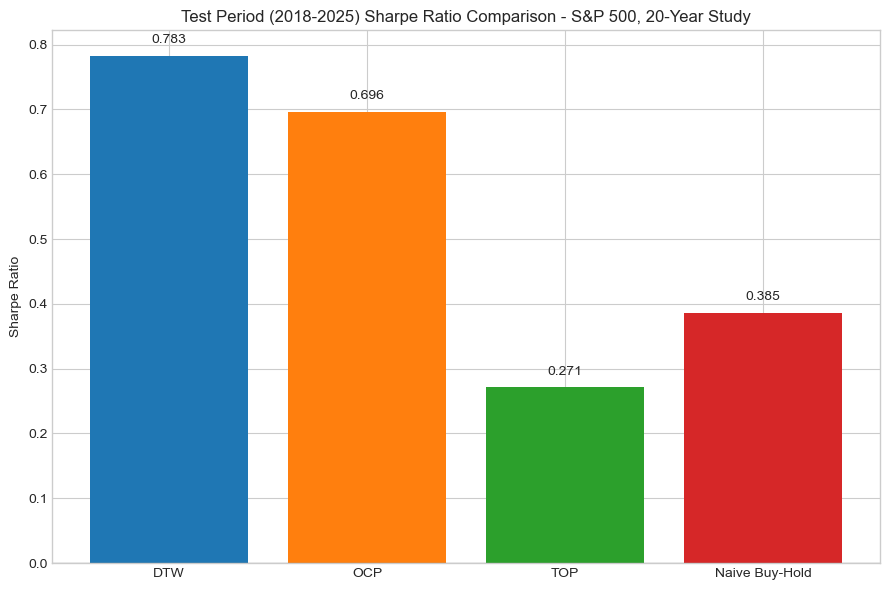

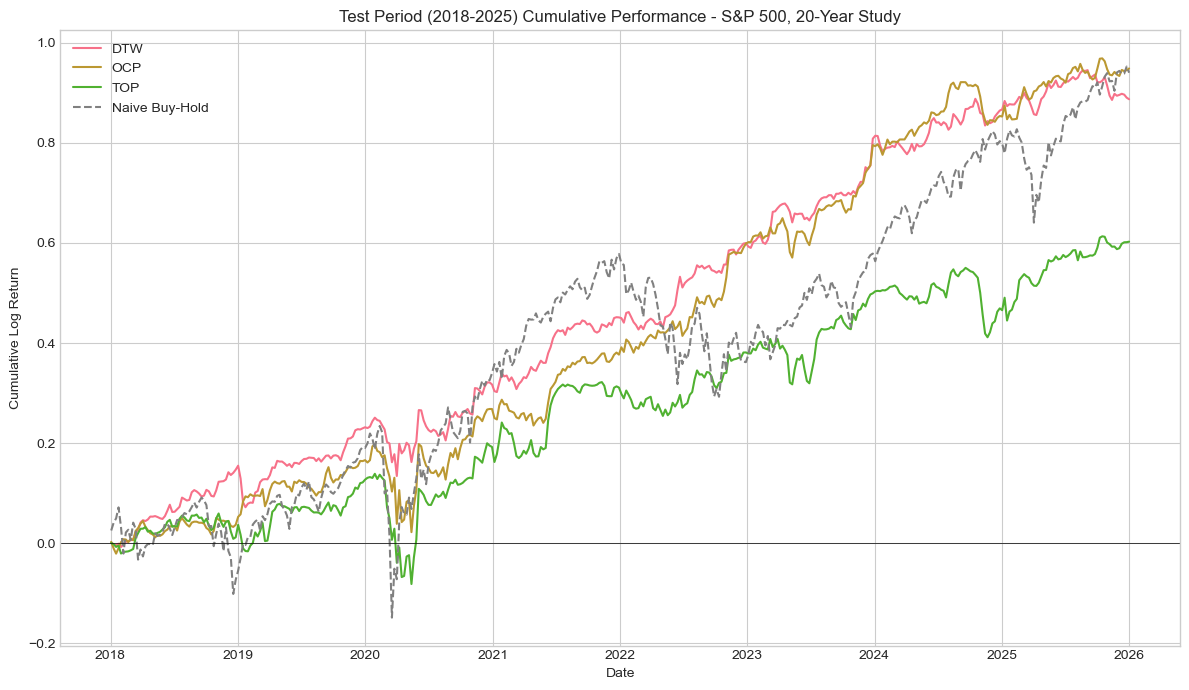


Saved: full_strategy_comparison_sp500_20y.csv, sharpe_comparison_test_sp500_20y.png, cumulative_pnl_test_sp500_20y.png


In [73]:
# Three period, four-strategy comparison summary

comparison_rows = []

# DTW/OCP/TOP: Train (sanity check), Test (reportable)
for method in ['DTW', 'OCP', 'TOP']:
    train_m = method_portfolio_results[method]['metrics']
    comparison_rows.append({'strategy':method, 'period': 'Train (sanity check)', **train_m})

    test_m = test_method_portfolio_results[method]['metrics']
    comparison_rows.append({'strategy': method, 'period': 'Test (reportable)', **test_m})

# Naive buy-and-hold: all three periods
for period_name in ['Train', 'Validation', 'Test']:
    label = f'{period_name} (reportable)' if period_name != 'Train' else 'Train (reportable)'
    comparison_rows.append({'strategy': 'Naive Buy-Hold', 'period': label, **naive_results[period_name]})

comparison_df = pd.DataFrame(comparison_rows)
print('Full Strategy Comparison Table:')
print(comparison_df[['strategy', 'period', 'total_return', 'sharpe', 'max_drawdown', 'win_rate']])

comparison_df.to_csv('full_strategy_comparison_sp500_20y.csv', index=False)

# Chart 1: Sharpe comparison bar chart, Test period only
test_comparison = comparison_df[comparison_df['period'] == 'Test (reportable)']

fig, ax = plt.subplots(figsize=(9,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(test_comparison['strategy'], test_comparison['sharpe'], color=colors)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Test Period (2018-2025) Sharpe Ratio Comparison - S&P 500, 20-Year Study')
for bar, val in zip(bars, test_comparison['sharpe']):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.02 if val >= 0 else -0.05),
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sharpe_comparison_test_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Cumulative PnL curves, Test period, all four strategies
fig, ax = plt.subplots(figsize=(12,7))

for method in ['DTW', 'OCP', 'TOP']:
    returns = test_method_portfolio_results[method]['returns']
    cumulative = returns.cumsum()
    ax.plot(cumulative.index, cumulative.values, label=method, linewidth=1.5)

naive_test_returns = benchmark_returns.loc[TEST_START:TEST_END]
naive_cumulative = naive_test_returns.cumsum()
ax.plot(naive_cumulative.index, naive_cumulative.values, label='Naive Buy-Hold',
        linewidth=1.5, linestyle='--', color='gray')

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Log Return')
ax.set_title('Test Period (2018-2025) Cumulative Performance - S&P 500, 20-Year Study')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('cumulative_pnl_test_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved: full_strategy_comparison_sp500_20y.csv, sharpe_comparison_test_sp500_20y.png, cumulative_pnl_test_sp500_20y.png')

In [74]:
# Sortino and Calmar ratios computed for extra analysis
def compute_sortino_calmar(returns_series, rf_annual=RISK_FREE_RATE):
    returns_series = returns_series.dropna()
    n_periods = len(returns_series)

    weekly_rf = rf_annual / 52
    excess_returns = returns_series - weekly_rf

    # Sortino: only penalizes downside volatility.
    # Using all periods in the denominator
    downside_returns = excess_returns.clip(upper=0)
    downside_deviation = np.sqrt((downside_returns ** 2).mean())
    sortino = (excess_returns.mean() / downside_deviation) * np.sqrt(52) if downside_deviation > 0 else 0.0

    # Calmar: annualized return  over max drawdown
    cumulative = returns_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max
    max_drawdown = drawdown.min()

    total_return = cumulative.iloc[-1] if n_periods > 0 else 0.0
    annualized_return = total_return * (52 / n_periods) if n_periods > 0 else 0.0
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0.0

    return {'sortino': sortino, 'calmar': calmar}

# Test-period results, DTW/OCP/TOP
sortino_calmar_results = []

for method in ['DTW', 'OCP', 'TOP']:
    sc = compute_sortino_calmar(test_method_portfolio_results[method]['returns'])
    sortino_calmar_results.append({'strategy': method, **sc})

# Naive, Test period
naive_test_returns = benchmark_returns.loc[TEST_START:TEST_END]
sc = compute_sortino_calmar(naive_test_returns)
sortino_calmar_results.append({'strategy': 'Naive Buy-Hold', **sc})

sortino_calmar_df = pd.DataFrame(sortino_calmar_results)
print('Sortino and Calmar Ratios (Test Period, 2018-2025):')
print(sortino_calmar_df)

sortino_calmar_df.to_csv('sortino_calmar_test_sp500_20y.csv', index=False)
print('\nSaved: sortino_calmar_test_sp500_20y.csv')

Sortino and Calmar Ratios (Test Period, 2018-2025):
         strategy  sortino  calmar
0             DTW   1.2840  0.9471
1             OCP   1.0528  0.6733
2             TOP   0.3936  0.3405
3  Naive Buy-Hold   0.5245  0.3055

Saved: sortino_calmar_test_sp500_20y.csv


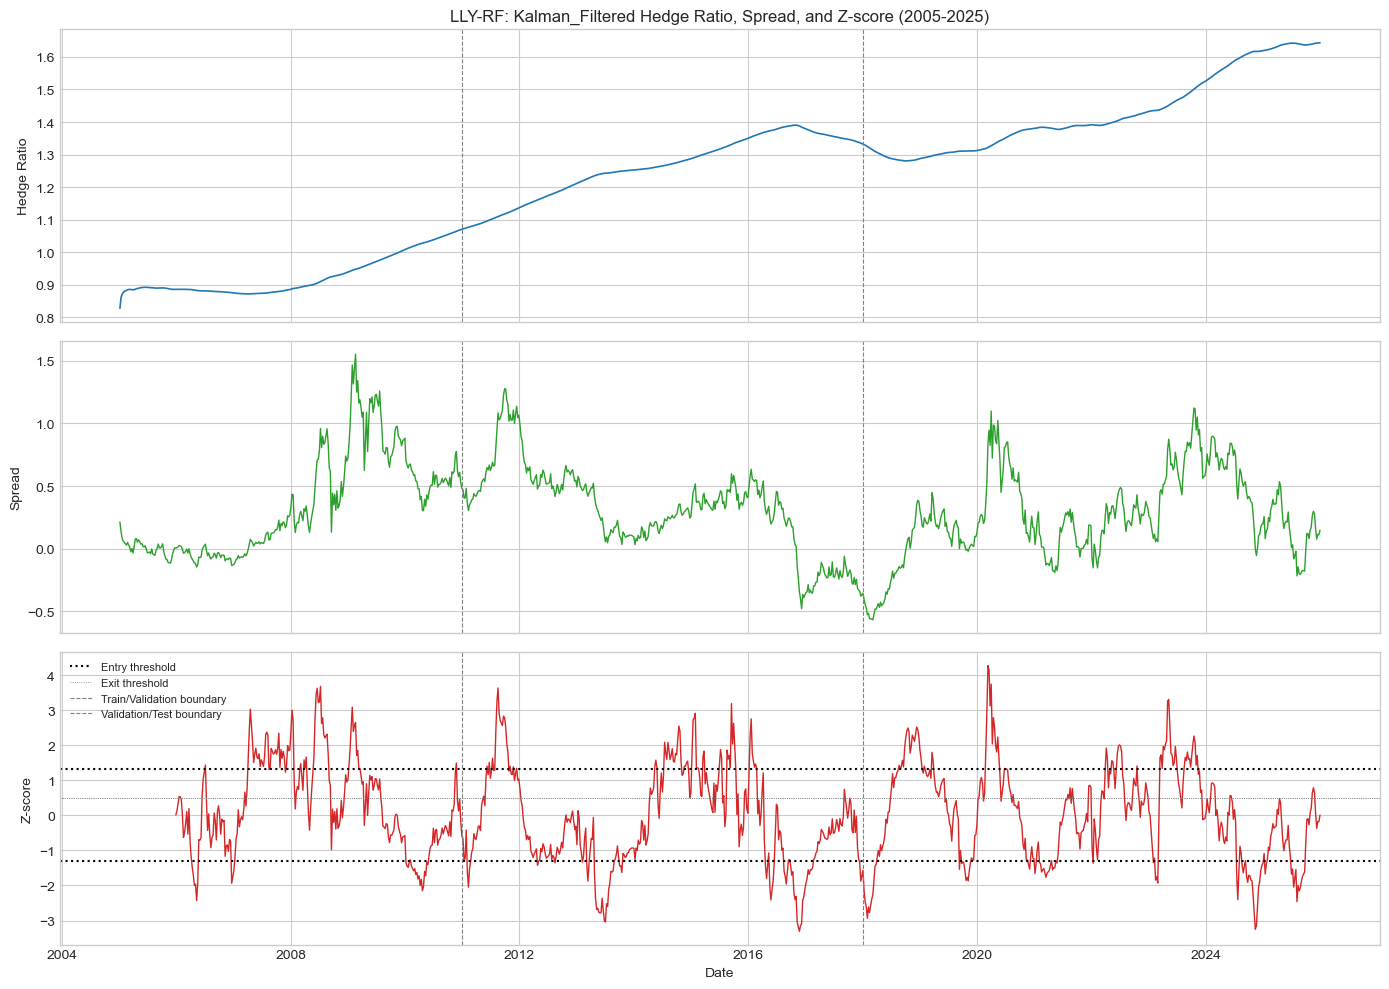

Saved: example_pair_LLY_RF_sp500_20y.png


In [77]:
# Publication figure: representative pair example (LLY-RF, found by both OCP and TOP)
example_keys = [k for k in kalman_results_full.keys() if k[1] == 'LLY' and k[2] == 'RF']
example_key = example_keys[0]

method, s1, s2 = example_key
spread = kalman_results_full[example_key]['spread']
hedge_ratio = kalman_results_full[example_key]['hedge_ratio']
dates = kalman_results_full[example_key]['dates']
regime = regime_results_full[example_key]['regime']

spread_series = pd.Series(spread, index=dates)
rolling_mean = spread_series.rolling(window=ZSCORE_WINDOW).mean()
rolling_std = spread_series.rolling(window=ZSCORE_WINDOW).std()
zscore = (spread_series - rolling_mean) / rolling_std

fig, axes = plt.subplots(3, 1, figsize=(14,10), sharex=True)

# Panel 1: hedge ratio over time
axes[0].plot(dates, hedge_ratio, color='#1f77b4', linewidth=1.2)
axes[0].axvline(x=pd.Timestamp(TRAIN_END), color='gray',  linestyle='--', linewidth=0.8)
axes[0].axvline(x=pd.Timestamp(VAL_END), color='gray', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Hedge Ratio')
axes[0].set_title(f'{s1}-{s2}: Kalman_Filtered Hedge Ratio, Spread, and Z-score (2005-2025)')

# Panel 2: spread
axes[1].plot(dates, spread, color='#2ca02c', linewidth=1.0)
axes[1].axvline(x=pd.Timestamp(TRAIN_END), color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(x=pd.Timestamp(VAL_END), color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Spread')

# Panel 3: Z-score with entry threshold (using chosen multiplier)
axes[2].plot(dates, zscore, color='#d62728', linewidth=1.0)
axes[2].axhline(y=STANDARD_ENTRY * CHOSEN_MULTIPLIER, color='black', linestyle=':', label='Entry threshold')
axes[2].axhline(y=-STANDARD_ENTRY * CHOSEN_MULTIPLIER, color='black', linestyle=':')
axes[2].axhline(y=EXIT_THRESHOLD, color='gray', linestyle=':',  linewidth=0.6, label='Exit threshold')
axes[2].axhline(y=EXIT_THRESHOLD, color='gray', linestyle=':',  linewidth=0.6)
axes[2].axvline(x=pd.Timestamp(TRAIN_END), color='gray', linestyle='--', linewidth=0.8, label='Train/Validation boundary')
axes[2].axvline(x=pd.Timestamp(VAL_END), color='gray', linestyle='--', linewidth=0.8, label='Validation/Test boundary')
axes[2].set_ylabel('Z-score')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left',fontsize=8)

plt.tight_layout()
plt.savefig('example_pair_LLY_RF_sp500_20y.png',  dpi=150, bbox_inches='tight')
plt.show()

print('Saved: example_pair_LLY_RF_sp500_20y.png')

Transaction Cost Sensitivity (Sharpe by cost level, Test Period 2018-2025):
cost_bps           0      5      10     20
strategy                                  
DTW            0.7827 0.7258 0.6688 0.5541
Naive Buy-Hold 0.3853 0.3789 0.3724 0.3589
OCP            0.6960 0.6490 0.6018 0.5075
TOP            0.2710 0.2313 0.1915 0.1119


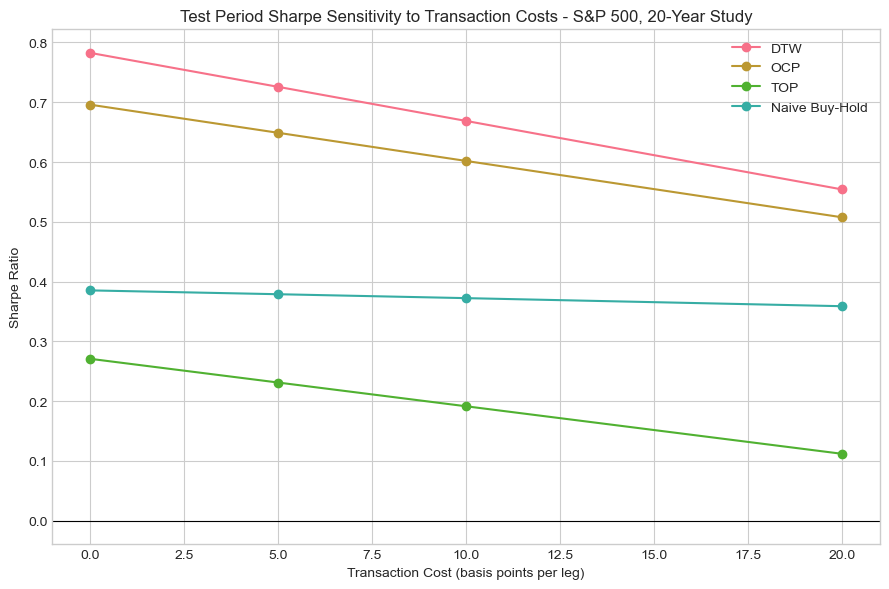


Saved: transaction_cost_sensitivity_sp500_20y.csv, transaction_cost_sensitivity_sp500_20y.png


In [80]:
# Transaction cost sensitivity

COST_LEVELS_BPS = [0, 5, 10, 20] # basis points per trade leg

def apply_transaction_costs(returns_series, signal_series, cost_bps):
    """
    Deducts a fixed cost (in basis points) on every week a position
    change occurs. A pair trade always has two legs (long one stock, 
    short the other), so each entry or exit event will incur 2 x cost_bps
    of drag, not just 1x.
    """
    position_changed= signal_series.diff().abs() > 0
    cost_per_change = 2 * (cost_bps / 10000)

    adjusted = returns_series.copy()
    adjusted[position_changed] = adjusted[position_changed] - cost_per_change
    return adjusted

# Computing each pair's signal once
test_signals_by_pair = {}
for key in test_pair_returns.keys():
    full_signal = generate_signal_for_pair(key, CHOSEN_MULTIPLIER, kalman_results_full, regime_results_full)
    test_signals_by_pair[key] = full_signal[full_signal.index > VAL_END].reindex(test_pair_returns[key].index)

transaction_cost_results = []

for cost_bps in COST_LEVELS_BPS:
    for method in ['DTW', 'OCP', 'TOP']:
        method_pairs = [k for k in test_pair_returns.keys() if k[0] == method]

        adjusted_pair_returns = {
            key: apply_transaction_costs(test_pair_returns[key], test_signals_by_pair[key], cost_bps)
            for key in method_pairs
        }

        portfolio_returns = pd.concat(list(adjusted_pair_returns.values()), axis=1).mean(axis=1)
        metrics = compute_backtest_metrics(portfolio_returns)
        sc = compute_sortino_calmar(portfolio_returns)

        transaction_cost_results.append({
            'cost_bps': cost_bps, 'strategy': method, 'sharpe': metrics['sharpe'],
            'sortino': sc['sortino'], 'calmar': sc['calmar'],
            'total_return': metrics['total_return'], 'max_drawdown': metrics['max_drawdown']
        })

    # Naive: one round trip for the whole holding period (buy at start, sell at end)
    naive_test_returns = benchmark_returns.loc[TEST_START:TEST_END].copy()
    naive_test_returns.iloc[0] = naive_test_returns.iloc[0] - 2 * (cost_bps / 1000)

    metrics = compute_backtest_metrics(naive_test_returns)
    sc = compute_sortino_calmar(naive_test_returns)
    transaction_cost_results.append({
        'cost_bps': cost_bps, 'strategy': 'Naive Buy-Hold', 'sharpe': metrics['sharpe'],
        'sortino': sc['sortino'], 'calmar': sc['calmar'],
        'total_return': metrics['total_return'], 'max_drawdown': metrics['max_drawdown']
    })

tc_df = pd.DataFrame(transaction_cost_results)
print('Transaction Cost Sensitivity (Sharpe by cost level, Test Period 2018-2025):')
print(tc_df.pivot(index='strategy', columns='cost_bps', values='sharpe').round(4))

# Publication figure: Sharpe degradation curve across cost levels
fig, ax = plt.subplots(figsize=(9,6))
for strategy in ['DTW','OCP','TOP','Naive Buy-Hold']:
    sub = tc_df[tc_df['strategy'] == strategy]
    ax.plot(sub['cost_bps'], sub['sharpe'], marker='o', label=strategy)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Transaction Cost (basis points per leg)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Test Period Sharpe Sensitivity to Transaction Costs - S&P 500, 20-Year Study')
ax.legend()
plt.tight_layout()
plt.savefig('transaction_cost_sensitivity_sp500_20y.png', dpi=150, bbox_inches='tight')
plt.show()

tc_df.to_csv('transaction_cost_sensitivity_sp500_20y.csv', index=False)
print('\nSaved: transaction_cost_sensitivity_sp500_20y.csv, transaction_cost_sensitivity_sp500_20y.png')

In [ ]:
# Statistical significance of Sharpe ratio differences 

def block_bootstrap_sharpe_diff(returns_a, returns_b, rf_annual=RISK_FREE_RATE,
                                n_boot, block_size=8, seed=42):
    """
    Block bootstrap test for whether two return series' Sharpe ratios
    differ significantly. Block (rather than individual weeks) are
    resampled to preserve serial correlation within each series, and 
    the SAME block indices are used for both series in each draw, to 
    preserve whatever relationship exists between them (e.g., both 
    reacting to the same market week).
    """
    

In [82]:
# Notebook Summary 
print('='*70)
print('SUMMARY:  DTW vs. OCP vs. TOP CLUSTERING FOR PAIRS TRADING')
print('S&P 500, 20-Year Study (2005-2025)')
print('='*70)

print("""
METHODOLOGY
    Universe: S&P 500 constituents as of 2005-01-01, survivorship-
              bias-free dataset, cleaned for delisting-date suffixes and 
              yfinance data availability (267 of 495 original constituents
              retained after cleaning)
    Periods:  Train 2005-2010 (6y, formation), Validation 2011-2017
              (7y, threshold tuning), Test 2018-2025 (7y, reportable)
    Design:   Formation-period methodology (Gatev, Goetzmann & 
              Rouwenthorst, 2006). Pairs selected once on Train via
              cointegration and traded forward unchanged through 
              Validatoin and Test. Kalman filter and regime baseline
              run as a single continuous online process across all
              three periods, never refit at period boundaries.
""")

print('='*70)
print('CLUSTERING AND CLUSTER VALIDATION')
print('='*70)
print("""
    All three distance metrics (DTW, OCP, TOP) independently converge on
    k=2 across all three cluster validation indices (Silhouette,
    Calinski-Harabasz, Davies-Bouldin) on Train-period data.
    TOP's original temperature of T=0.5 produced negative free energies 
    (mathematically valid under the Sornette-Zhou thermal formulation, 
    but invalid as a distance metric for hierarchical clustering). 
    T=0.25 was selected as the largest tested value remaining fully 
    non-negative while staying substantially differentiated from OCP. 
    A residual 0.6% of pairs still produced negative values at T=0.25
    and were corrected via an additive constant shift, preserving relative 
    structure.
""")

print('='*70)
print('PAIRWISE CLUSTERING AGREEMENT (ADJUSTED RANDOM INDEX)')
print('='*70)
print("""
    OCP and TOP display the highest pairwise agreement of any method pair
    at every tested k value (k=2: 0.7395, k=7: 0.3479, k=7: 0.3302),
    consistenly exceeding DTW's agreement with either. This indicates 
    the shared causality constraint is the primary driver of cluster 
    structure agreement between OCP and TOP, rather than the specific 
    single-path of OCP or the thermal-ensemble treatment of TOP.
""")

print('='*70)
print('COINTEGRATION TESTING (ENGLE-GRANGER, BENJAMINI-HOCHBERG CORRECTED)')
print('='*70)
print("""
    Tested within k=7 clusters, Train period only.
    DTW: 6,271 pairs tested, 17 significant (0.27%)
    OCP: 5,789 pairs tested, 20 significant (0.35%)
    TOP: 6,016 pairs tested, 16 significant (0.27%)
    LLY-RF was independently indentified as significant by both OCP and 
    TOP, a concrete instance of the ARI agreement finding above.
""")

print('='*70)
print('VALIDATION-PERIOD THRESHOLD SELECTION')
print('='*70)
print("""
    A single entry-threshold multiplier was applied identically 
    across all three clustering methods to preserve a fair 
    comparison. The multiplier was selected by maximizing pooled 
    Sharpe ratio across DTW, OCP, and TOP combined, subject to a 
    50% pair-activity floor. Five candidates were tested (0.75, 
    0.85, 1.0, 1.15, 1.25), and all five candidates reached 100% 
    trading activity across all pairs, so the activity floor did 
    not bind in this instance. Multiplier = 0.75 was selected (pooled
    Sharpe 0.3384).
""")

print('='*70)
print('TEST PERIOD RESULTS (2018-2025, REPORTABLE)')
print('='*70)
print(f"""
    {'Strategy':<15}{'Sharpe':>10}{'Sortino':>10}{'Calmar':>10}{'Return':>10}{'Max DD':>10}
    {'-'*65}
    {'DTW':<15}{0.7827:>10.3f}{1.284:>10.3f}{0.947:>10.3f}{0.8872:>10.3f}{-0.1165:>10.3f}
    {'OCP':<15}{0.6960:>10.3f}{1.053:>10.3f}{0.673:>10.3f}{0.9486:>10.3f}{-0.1753:>10.3f}
    {'TOP':<15}{0.2710:>10.3f}{0.394:>10.3f}{0.341:>10.3f}{0.6026:>10.3f}{-0.2202:>10.3f}
    {'Naive B&H':<15}{0.3853:>10.3f}{0.525:>10.3f}{0.306:>10.3f}{0.9402:>10.3f}{-0.3829:>10.3f}
""")

print('='*70)
print('KEY FINDINGS')
print('='*70)
print("""
    1.  DTW and OCP substantially outperform naive buy-and-hold on every 
        risk-adjusted metric (Sharpe, Sortino, Calmar) while carrying a 
        fraction of its maximum drawdown, despite comparable or lower raw
        total return. TOP underperforms (T=0.25) naive on Sharpe and Sortino 
        but marginally exceeds it on Calmar, highlighting that different 
        risk-adjusted metrics can rank strategies differently depending
        on whether volatility or agregate drawdown is penalized.

    2.  Statistical similarity in pair selection does not predict similarity 
        in trading outcome. OCP and TOP showed the strongest custering 
        agreement (ARI) of any method pair, yet diverged most sharply in 
        Test-period performance, while OCP tracked DTW's performance more
        closely despite weaker clustering agreement with it. This echoes the 
        cointegration-strength versus probability disconnect observed in 
        previous work on this dataset.

    3.  TOP's weaker performance can't be attributed to the causality 
        constraint itself, since OCP operates under the same constraint 
        and performs comparably to unconstrained DTW. The gap is more 
        likely specific to TOP's thermal-ensemble path averaging, it's 
        temperature calibration, or both.

    4.  Including transaction costs via the use of basis point deduction
        (0, 5, 10, 20) illustrate that DTW & OCP have higher risk-adjusted
        metrics than naive buy-and-hold regardless. Naive buy-and-hold 
        degrades conservatively, from a Sharpe of 0.3853 to 0.3589, while the 
        decrease in Sharpe is more pronounced in DTW & OCP ( DTW: 0.7827 to
        0.5541, OCP: 0.6960 to 0.5075, both at the most extreme 20 bps tested). 
        TOP shows the strongest degradation of any strategy, falling from 
        0.2710 to 0.1119 at 20 bps, consistent with it's weakest Sharpe-based 
        performance among all four strategies across every cost-level.  
""")

print('='*70)
print('LIMITATIONS')
print('='*70)
print("""
    - The Validation threshold grid (5 candidates) was drawn from a 
      single 7-year window. A wider grid or multiple independent 
      Validation windows would strengthen confidence in the selected
      multiplier.
    - TOP's temperature (T=0.25) was calibrated empirically against this
      dataset rather than derived theoretically.
    - Results reflect a single historical 20-year path rather than 
      repeated independent trails. Some of the observed performance 
      gap between methods may be path-dependent.
    - yfinance-sourced price data showed minor non-determinism across 
      download sessions, producing small (single-digit percent) shifts
      in cluster membership on various reruns. The qualitative findings 
      above (k=2 convergence, OCP-TOP ARI dominance) were confirmed 
      stable across multiple independent downloads.
""")


SUMMARY:  DTW vs. OCP vs. TOP CLUSTERING FOR PAIRS TRADING
S&P 500, 20-Year Study (2005-2025)

METHODOLOGY
    Universe: S&P 500 constituents as of 2005-01-01, survivorship-
              bias-free dataset, cleaned for delisting-date suffixes and 
              yfinance data availability (267 of 495 original constituents
              retained after cleaning)
    Periods:  Train 2005-2010 (6y, formation), Validation 2011-2017
              (7y, threshold tuning), Test 2018-2025 (7y, reportable)
    Design:   Formation-period methodology (Gatev, Goetzmann & 
              Rouwenthorst, 2006). Pairs selected once on Train via
              cointegration and traded forward unchanged through 
              Validatoin and Test. Kalman filter and regime baseline
              run as a single continuous online process across all
              three periods, never refit at period boundaries.

CLUSTERING AND CLUSTER VALIDATION

    All three distance metrics (DTW, OCP, TOP) independently conver